## Imports and Funcitons

In [1]:
# =============================================================================
# NIH CXR Feature Extraction ReID Experiment
# =============================================================================
# Uses utility models (trained for pathology classification) as feature
# extractors. Tests whether penultimate layer embeddings accidentally encode
# patient-identifiable anatomical information — and how GS affects this.
#
# Key difference from classification ReID:
#   - Models were NEVER told about patient identity
#   - We extract embeddings then do cosine similarity retrieval
#   - Gallery: half of each patient's images (reference)
#   - Probe  : other half (query)
#
# Evaluation:
#   Adaptive : model trained on GS-X, images transformed with GS-X
#   Blind    : model trained on GS-X, images are raw
#   Splits   : train, val, test (all three from utility experiment)
# =============================================================================

import os
import gc
import re
import json
import math
import random
import warnings
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any
from collections import defaultdict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as tvm
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
warnings.filterwarnings('ignore')

# =============================================================================
# PATHS
# =============================================================================
PROJECT_ROOT    = Path('.')
DATA_DIR        = PROJECT_ROOT / 'data'    / 'chest' / 'npz'
TENSOR_DIR      = PROJECT_ROOT / 'cache'   / 'nih_cxr' / 'utility' / 'tensors'
MODELS_DIR      = PROJECT_ROOT / 'models'  / 'nih_cxr' / 'utility'
META_DIR        = PROJECT_ROOT / 'data'    / 'metadata'
RESULTS_DIR     = PROJECT_ROOT / 'results' / 'nih_cxr' / 'reid_feature_ext'
FIG_DIR         = RESULTS_DIR  / 'figures'

for d in [RESULTS_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

MASTER_CSV = RESULTS_DIR / 'NIH_CXR_ReID_FeatureExt.csv'

# =============================================================================
# CONFIG
# =============================================================================
GLOBAL_SEED   = 1337
DEVICE        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

ARCHITECTURES = ['resnet18', 'densenet121']
INITS         = ['pretrained', 'scratch']
CONDITIONS    = ['raw', 'gs50', 'gs40', 'gs30', 'gs20', 'gs10', 'gs0']
EVAL_SPLITS   = ['train', 'val', 'test']
ATTACKERS     = ['adaptive', 'blind']

# Gallery/probe K caps — matches OASIS
K_PROBE_LIST   = [1]
K_GALLERY_LIST = [1, 3, 5]

# Minimum images per patient to be included in gallery/probe
MIN_IMAGES_PER_PATIENT = 2

# Utility model constants — must match utility experiment
NUM_CLASSES   = 11
DROPOUT_P     = 0.5
BATCH_SIZE_EMB = 128

# GS params (for on-the-fly if needed — not used since tensors pre-built)
GS_BATCH_SIZE = 100
GS_ITERS      = 50

RESUME_IF_EXISTS = True

random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)

if torch.cuda.is_available():
    print(f"GPU  : {torch.cuda.get_device_name(0)}")
    print(f"VRAM : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

print(f"\nDevice      : {DEVICE}")
print(f"Conditions  : {CONDITIONS}")
print(f"Eval splits : {EVAL_SPLITS}")
print(f"Results     : {RESULTS_DIR}")

def _hard_fail(msg: str):
    raise RuntimeError(f"[HARD FAIL] {msg}")

GPU  : NVIDIA L4
VRAM : 23.6 GB

Device      : cuda
Conditions  : ['raw', 'gs50', 'gs40', 'gs30', 'gs20', 'gs10', 'gs0']
Eval splits : ['train', 'val', 'test']
Results     : results/nih_cxr/reid_feature_ext


In [2]:
# =============================================================================
# DATA LOADING
# =============================================================================
# Load raw NPZ splits (images + subject_ids for gallery/probe construction)
# Load pre-built GS tensors for all conditions × splits
# =============================================================================

def load_npz_split(
    split : str,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Load utility NPZ split.
    Returns:
        images      : (N, 224, 224) float32
        labels      : (N,) int64
        subject_ids : (N,) int64
    """
    path = DATA_DIR / f'{split}.npz'
    if not path.exists():
        _hard_fail(f"NPZ not found: {path}")
    data        = np.load(path)
    images      = data['images'].astype(np.float32)
    labels      = data['labels'].astype(np.int64)
    subject_ids = data['subject_ids'].astype(np.int64)
    data.close()
    return images, labels, subject_ids


def load_tensor(split: str, condition: str) -> torch.Tensor:
    """
    Load pre-built tensor for a split/condition pair.
    Returns (N, 1, 224, 224) float32 tensor.
    """
    path = TENSOR_DIR / f'{split}_{condition}.pt'
    if not path.exists():
        _hard_fail(f"Tensor not found: {path}")
    obj = torch.load(path, map_location='cpu', weights_only=False)
    x   = obj['x']   # (N, 1, 224, 224)
    return x


# ── Load raw splits ───────────────────────────────────────────────────────────
print("=== LOADING RAW NPZ SPLITS ===\n")
split_data = {}
for split in EVAL_SPLITS:
    images, labels, sids = load_npz_split(split)
    split_data[split] = {
        'images' : images,
        'labels' : labels,
        'sids'   : sids,
    }
    n_multi = sum(
        1 for pid in np.unique(sids)
        if (sids == pid).sum() >= MIN_IMAGES_PER_PATIENT
    )
    print(f"  {split:<6} : {len(images):>6,} images  "
          f"{len(np.unique(sids)):>5,} patients  "
          f"{n_multi:>5,} patients with ≥{MIN_IMAGES_PER_PATIENT} images")

# ── Verify all tensors exist ──────────────────────────────────────────────────
print(f"\n=== VERIFYING PRE-BUILT TENSORS ===\n")
missing = []
for split in EVAL_SPLITS:
    for cond in CONDITIONS:
        p = TENSOR_DIR / f'{split}_{cond}.pt'
        status = '✓' if p.exists() else '✗'
        size   = f"({p.stat().st_size/1e9:.2f}GB)" if p.exists() else ''
        print(f"  {status} {split}_{cond}.pt {size}")
        if not p.exists():
            missing.append(f'{split}_{cond}')

if missing:
    print(f"\n⚠ Missing tensors: {missing}")
    print("  Val/train GS tensors may be missing — "
          "will fall back to test tensors only")
else:
    print(f"\n✓ All {len(EVAL_SPLITS)*len(CONDITIONS)} tensors available")

print("\n✓ Data loading ready")

=== LOADING RAW NPZ SPLITS ===

  train  : 24,654 images  9,436 patients  3,843 patients with ≥2 images
  val    :  3,725 images  1,346 patients    599 patients with ≥2 images
  test   :  6,802 images  2,699 patients  1,060 patients with ≥2 images

=== VERIFYING PRE-BUILT TENSORS ===

  ✓ train_raw.pt (4.95GB)
  ✓ train_gs50.pt (4.95GB)
  ✓ train_gs40.pt (4.95GB)
  ✓ train_gs30.pt (4.95GB)
  ✓ train_gs20.pt (4.95GB)
  ✓ train_gs10.pt (4.95GB)
  ✓ train_gs0.pt (4.95GB)
  ✓ val_raw.pt (0.75GB)
  ✓ val_gs50.pt (0.75GB)
  ✓ val_gs40.pt (0.75GB)
  ✓ val_gs30.pt (0.75GB)
  ✓ val_gs20.pt (0.75GB)
  ✓ val_gs10.pt (0.75GB)
  ✓ val_gs0.pt (0.75GB)
  ✓ test_raw.pt (1.37GB)
  ✓ test_gs50.pt (1.37GB)
  ✓ test_gs40.pt (1.37GB)
  ✓ test_gs30.pt (1.37GB)
  ✓ test_gs20.pt (1.37GB)
  ✓ test_gs10.pt (1.37GB)
  ✓ test_gs0.pt (1.37GB)

✓ All 21 tensors available

✓ Data loading ready


In [3]:
# =============================================================================
# GALLERY / PROBE CONSTRUCTION
# =============================================================================
# For each patient with ≥2 images: split 50/50 into gallery and probe.
# Patients with <2 images are excluded.
# Deterministic per-patient shuffle using subject ID as seed component.
# =============================================================================

MIN_GALLERY_PER_SUBJ = 1
MIN_PROBE_PER_SUBJ   = 1
GALLERY_FRACTION     = 0.5


def build_gallery_probe(
    split      : str,
    k_gallery  : Optional[int] = None,
    k_probe    : Optional[int] = None,
    seed       : int = GLOBAL_SEED,
) -> Dict:
    """
    Build gallery/probe split from a utility NPZ split.

    - Patients with < MIN_IMAGES_PER_PATIENT images are excluded
    - Per-patient deterministic 50/50 shuffle
    - k_gallery/k_probe caps max images per patient per side

    Returns dict with:
        gallery: {x_idx, sid}   indices into split tensor
        probe  : {x_idx, sid}   indices into split tensor
        n_subjects: int
    """
    sids    = split_data[split]['sids']
    n_total = len(sids)

    # Group indices by subject
    groups = defaultdict(list)
    for i, sid in enumerate(sids):
        groups[int(sid)].append(i)

    gallery_idx, gallery_sid = [], []
    probe_idx,   probe_sid   = [], []
    kept_subjects = []

    for pid, idxs in sorted(groups.items()):
        if len(idxs) < MIN_IMAGES_PER_PATIENT:
            continue

        # Deterministic per-patient shuffle
        r = random.Random(hash((seed, pid)) & 0xFFFFFFFF)
        idxs_shuf = idxs.copy()
        r.shuffle(idxs_shuf)

        n   = len(idxs_shuf)
        n_g = max(int(math.floor(n * GALLERY_FRACTION)),
                  MIN_GALLERY_PER_SUBJ)
        n_g = min(n_g, n - MIN_PROBE_PER_SUBJ)

        g = idxs_shuf[:n_g]
        p = idxs_shuf[n_g:]

        if len(g) < MIN_GALLERY_PER_SUBJ or \
           len(p) < MIN_PROBE_PER_SUBJ:
            continue

        # Apply K caps
        if k_gallery is not None:
            g = g[:k_gallery]
        if k_probe is not None:
            p = p[:k_probe]

        if len(g) < MIN_GALLERY_PER_SUBJ or \
           len(p) < MIN_PROBE_PER_SUBJ:
            continue

        gallery_idx.extend(g)
        gallery_sid.extend([str(pid)] * len(g))
        probe_idx.extend(p)
        probe_sid.extend([str(pid)] * len(p))
        kept_subjects.append(pid)

    if len(kept_subjects) == 0:
        _hard_fail(
            f"No subjects with ≥{MIN_IMAGES_PER_PATIENT} "
            f"images in split '{split}'"
        )

    return {
        'gallery': {
            'x_idx' : gallery_idx,
            'sid'   : gallery_sid,
        },
        'probe': {
            'x_idx' : probe_idx,
            'sid'   : probe_sid,
        },
        'n_subjects' : len(kept_subjects),
        'split'      : split,
    }


# ── Smoke test ────────────────────────────────────────────────────────────────
print("=== GALLERY/PROBE SMOKE TEST ===\n")
for split in EVAL_SPLITS:
    gp = build_gallery_probe(split, k_gallery=3, k_probe=1)
    print(f"  {split:<6} : "
          f"{gp['n_subjects']:,} subjects  "
          f"gallery={len(gp['gallery']['x_idx']):,}  "
          f"probe={len(gp['probe']['x_idx']):,}")

    # Verify no index overlap
    g_set = set(gp['gallery']['x_idx'])
    p_set = set(gp['probe']['x_idx'])
    assert len(g_set & p_set) == 0, \
        f"LEAKAGE: gallery/probe index overlap in {split}"

    # Verify subject overlap (must have same subjects in both)
    g_subjs = set(gp['gallery']['sid'])
    p_subjs = set(gp['probe']['sid'])
    assert g_subjs == p_subjs, \
        f"Subject mismatch in {split}: " \
        f"{len(g_subjs - p_subjs)} gallery-only, " \
        f"{len(p_subjs - g_subjs)} probe-only"

print("\n✓ Gallery/probe construction ready")

=== GALLERY/PROBE SMOKE TEST ===

  train  : 3,843 subjects  gallery=6,453  probe=3,843
  val    : 599 subjects  gallery=1,018  probe=599
  test   : 1,060 subjects  gallery=1,735  probe=1,060

✓ Gallery/probe construction ready


In [4]:
# =============================================================================
# MODEL FACTORY AND EMBEDDING EXTRACTOR
# =============================================================================
# Matches utility experiment architecture exactly.
# Builds penultimate extractor — strips classification head,
# returns L2-normalised 512-dim (ResNet18) or 1024-dim (DenseNet121) embeddings.
# =============================================================================

def _strip_prefix(sd: dict) -> dict:
    if any(k.startswith('module.') for k in sd):
        return {k.replace('module.', '', 1): v for k, v in sd.items()}
    return sd


def _looks_like_state_dict(d: dict) -> bool:
    if not isinstance(d, dict) or len(d) == 0:
        return False
    return all(
        isinstance(k, str) and torch.is_tensor(v)
        for k, v in list(d.items())[:10]
    )


def build_model_like_utility(arch: str, init: str) -> nn.Module:
    """
    Reconstruct utility model architecture.
    Matches utility experiment exactly:
      - Mean-channel conv1 adaptation for pretrained
      - Sequential(Dropout, Linear) head
      - Partial freeze pattern for pretrained
    """
    pretrained = (init.lower() == 'pretrained')
    weights    = None
    if pretrained:
        weights = (tvm.ResNet18_Weights.DEFAULT
                   if arch == 'resnet18'
                   else tvm.DenseNet121_Weights.DEFAULT)

    if arch == 'resnet18':
        model    = tvm.resnet18(weights=weights)
        old_conv = model.conv1
        model.conv1 = nn.Conv2d(
            1, 64, kernel_size=7, stride=2, padding=3, bias=False
        )
        if pretrained:
            with torch.no_grad():
                model.conv1.weight.copy_(
                    old_conv.weight.mean(dim=1, keepdim=True)
                )
        else:
            nn.init.kaiming_normal_(
                model.conv1.weight, mode='fan_out', nonlinearity='relu'
            )
        model.fc = nn.Sequential(
            nn.Dropout(p=DROPOUT_P),
            nn.Linear(model.fc.in_features, NUM_CLASSES)
        )
        return model

    if arch == 'densenet121':
        model    = tvm.densenet121(weights=weights,
                                   memory_efficient=True)
        old_conv = model.features.conv0
        model.features.conv0 = nn.Conv2d(
            1, 64, kernel_size=7, stride=2, padding=3, bias=False
        )
        if pretrained:
            with torch.no_grad():
                model.features.conv0.weight.copy_(
                    old_conv.weight.mean(dim=1, keepdim=True)
                )
        else:
            nn.init.kaiming_normal_(
                model.features.conv0.weight,
                mode='fan_out', nonlinearity='relu'
            )
        model.classifier = nn.Sequential(
            nn.Dropout(p=DROPOUT_P),
            nn.Linear(model.classifier.in_features, NUM_CLASSES)
        )
        return model

    _hard_fail(f"Unknown arch: {arch}")


def load_utility_model(
    arch      : str,
    init      : str,
    condition : str,
) -> nn.Module:
    """Load best utility checkpoint for arch/init/condition."""
    path = MODELS_DIR / arch / init / condition / 'best.pt'
    if not path.exists():
        _hard_fail(f"Utility checkpoint not found: {path}")

    obj = torch.load(path, map_location='cpu', weights_only=True)
    sd  = _strip_prefix(obj if _looks_like_state_dict(obj)
                        else obj.get('state_dict', obj))

    model = build_model_like_utility(arch, init)
    model.load_state_dict(sd, strict=True)
    model.eval().to(DEVICE)
    return model


def build_penultimate_extractor(
    model : nn.Module,
    arch  : str,
) -> nn.Module:
    """
    Build feature extractor from penultimate layer.
    Strips classification head — returns pooled feature vector.
    ResNet18   → 512-dim after avgpool
    DenseNet121→ 1024-dim after adaptive_avg_pool2d
    """
    if arch == 'resnet18':
        class ResNet18Embedder(nn.Module):
            def __init__(self, m):
                super().__init__()
                self.m = m
            def forward(self, x):
                x = self.m.conv1(x)
                x = self.m.bn1(x)
                x = self.m.relu(x)
                x = self.m.maxpool(x)
                x = self.m.layer1(x)
                x = self.m.layer2(x)
                x = self.m.layer3(x)
                x = self.m.layer4(x)
                x = self.m.avgpool(x)
                return torch.flatten(x, 1)
        return ResNet18Embedder(model).eval().to(DEVICE)

    if arch == 'densenet121':
        class DenseNet121Embedder(nn.Module):
            def __init__(self, m):
                super().__init__()
                self.m = m
            def forward(self, x):
                x = self.m.features(x)
                x = F.relu(x, inplace=False)
                x = F.adaptive_avg_pool2d(x, (1, 1))
                return torch.flatten(x, 1)
        return DenseNet121Embedder(model).eval().to(DEVICE)

    _hard_fail(f"Unknown arch for embedder: {arch}")


@torch.no_grad()
def extract_embeddings(
    x       : torch.Tensor,   # (N, 1, H, W)
    embedder: nn.Module,
) -> torch.Tensor:
    """Extract L2-normalised embeddings in batches."""
    outs = []
    for i in range(0, x.shape[0], BATCH_SIZE_EMB):
        xb = x[i:i + BATCH_SIZE_EMB].to(DEVICE, non_blocking=True)
        eb = embedder(xb).float()
        eb = F.normalize(eb, p=2, dim=1)
        outs.append(eb.detach().cpu())
    return torch.cat(outs, dim=0)


def mean_embeddings_by_subject(
    emb      : torch.Tensor,
    sid_list : List[str],
) -> Tuple[torch.Tensor, List[str]]:
    """Average embeddings per subject and re-normalise."""
    groups   = defaultdict(list)
    for i, s in enumerate(sid_list):
        groups[s].append(i)
    subj_ids  = sorted(groups.keys())
    subj_embs = []
    for s in subj_ids:
        idx = groups[s]
        m   = emb[idx].mean(dim=0, keepdim=True)
        m   = F.normalize(m, p=2, dim=1)
        subj_embs.append(m)
    return torch.cat(subj_embs, dim=0), subj_ids


# ── Smoke test ────────────────────────────────────────────────────────────────
print("=== MODEL FACTORY SMOKE TEST ===\n")
for arch in ARCHITECTURES:
    for init in INITS:
        m = load_utility_model(arch, init, 'raw')
        e = build_penultimate_extractor(m, arch)
        x = torch.zeros(2, 1, 224, 224).to(DEVICE)
        with torch.no_grad():
            out = e(x)
        print(f"  {arch:<15} {init:<12} "
              f"embed_dim={out.shape[1]}  "
              f"norm={out.norm(dim=1).mean():.4f}")
        del m, e, x, out
        torch.cuda.empty_cache()

print("\n✓ Model factory and embedding extractor ready")

=== MODEL FACTORY SMOKE TEST ===

  resnet18        pretrained   embed_dim=512  norm=16.7608
  resnet18        scratch      embed_dim=512  norm=6.5927
  densenet121     pretrained   embed_dim=1024  norm=40.2175
  densenet121     scratch      embed_dim=1024  norm=15.1668

✓ Model factory and embedding extractor ready


In [5]:
# =============================================================================
# RETRIEVAL AND VERIFICATION METRICS
# =============================================================================

def cosine_sim_matrix(
    A : torch.Tensor,   # (N, D)
    B : torch.Tensor,   # (M, D)
) -> torch.Tensor:
    """Cosine similarity matrix (N, M). Both inputs assumed L2-normalised."""
    return A @ B.T


def _softmax_top1_prob(
    sims : np.ndarray,
    tau  : float = 0.07,
) -> float:
    """Softmax probability of top-1 match."""
    z    = sims / tau
    z   -= np.max(z)
    expz = np.exp(z)
    return float(np.max(expz / np.sum(expz)))


def compute_retrieval_metrics(
    probe_emb   : torch.Tensor,
    probe_sid   : List[str],
    gallery_emb : torch.Tensor,
    gallery_sid : List[str],
) -> Dict:
    """
    Compute retrieval metrics (Rank-1, Rank-5, margin, etc.)
    for probe vs gallery cosine similarity.
    """
    sim         = cosine_sim_matrix(probe_emb, gallery_emb).cpu().numpy()
    gallery_sid = np.asarray(gallery_sid)
    probe_sid   = np.asarray(probe_sid)

    ranks, top1_sim, margin, p_top1 = [], [], [], []

    for i in range(sim.shape[0]):
        sims        = sim[i]
        order       = np.argsort(-sims)
        correct_sid = probe_sid[i]
        ranked_sids = gallery_sid[order]

        pos = np.where(ranked_sids == correct_sid)[0]
        if len(pos) == 0:
            _hard_fail(
                f"Probe subject {correct_sid} not found in gallery. "
                f"Gallery subjects: {np.unique(gallery_sid)[:5]}"
            )

        rank = int(pos[0]) + 1
        ranks.append(rank)

        s1 = sims[order[0]]
        s2 = sims[order[1]] if len(order) > 1 else s1
        top1_sim.append(float(s1))
        margin.append(float(s1 - s2))
        p_top1.append(_softmax_top1_prob(sims))

    ranks = np.array(ranks)
    return {
        'rank1'    : float(np.mean(ranks == 1)),
        'rank5'    : float(np.mean(ranks <= 5)),
        'top1_sim' : float(np.mean(top1_sim)),
        'margin'   : float(np.mean(margin)),
        'p_top1'   : float(np.mean(p_top1)),
    }


def compute_verification_metrics(
    probe_emb   : torch.Tensor,
    probe_sid   : List[str],
    gallery_emb : torch.Tensor,
    gallery_sid : List[str],
    neg_per_probe : int = 200,
    seed          : int = GLOBAL_SEED,
) -> Dict:
    """
    Compute verification AUC (binary same/different patient).
    Uses bounded negative sampling to avoid O(N²) pairs.
    """
    sim         = cosine_sim_matrix(probe_emb, gallery_emb).cpu().numpy()
    probe_sid   = np.asarray(probe_sid)
    gallery_sid = np.asarray(gallery_sid)

    rng = np.random.default_rng(seed)
    y_true, y_score = [], []

    subj_to_gidx = defaultdict(list)
    for j, s in enumerate(gallery_sid):
        subj_to_gidx[s].append(j)
    all_gidx = np.arange(len(gallery_sid))

    for i in range(sim.shape[0]):
        s_probe  = probe_sid[i]
        pos_idx  = np.array(subj_to_gidx.get(s_probe, []), dtype=int)
        if pos_idx.size == 0:
            continue
        y_true.extend([1] * len(pos_idx))
        y_score.extend(sim[i, pos_idx].tolist())

        neg_pool = all_gidx[gallery_sid != s_probe]
        if neg_pool.size == 0:
            continue
        k       = min(neg_per_probe, neg_pool.size)
        neg_idx = rng.choice(neg_pool, size=k, replace=False)
        y_true.extend([0] * k)
        y_score.extend(sim[i, neg_idx].tolist())

    y_true  = np.asarray(y_true,  dtype=int)
    y_score = np.asarray(y_score, dtype=float)

    if len(np.unique(y_true)) < 2:
        return {
            'auc'            : float('nan'),
            'tar_at_far_1pct': float('nan'),
            'mean_sim_same'  : float('nan'),
            'mean_sim_diff'  : float('nan'),
        }

    auc        = float(roc_auc_score(y_true, y_score))
    pos_scores = y_score[y_true == 1]
    neg_scores = y_score[y_true == 0]
    thresh     = np.percentile(neg_scores, 99.0)
    tar        = float(np.mean(pos_scores >= thresh))

    return {
        'auc'            : auc,
        'tar_at_far_1pct': tar,
        'mean_sim_same'  : float(pos_scores.mean()),
        'mean_sim_diff'  : float(neg_scores.mean()),
    }


print("✓ Metrics functions ready")

✓ Metrics functions ready


## Main Execution Loop

In [ ]:
# =============================================================================
# MAIN EXPERIMENT LOOP
# =============================================================================

def run_feature_ext_reid():

    # ── Resume guard ──────────────────────────────────────────────────────────
    if RESUME_IF_EXISTS and MASTER_CSV.exists():
        df_existing = pd.read_csv(MASTER_CSV)
        existing_rows = df_existing.to_dict('records')
        done_keys = set(
            (r['arch'], r['init'], r['train_condition'],
             r['attacker_type'], r['eval_split'],
             r['k_gallery'], r['k_probe'], r['level'])
            for r in existing_rows
        )
        print(f"🔄 Loaded {len(existing_rows)} existing rows — "
              f"resuming from checkpoint")
    else:
        existing_rows = []
        done_keys     = set()
        print("🆕 Starting fresh")

    all_rows = list(existing_rows)

    print(f"\n{'='*70}")
    print(f"NIH CXR Feature Extraction ReID")
    print(f"{'='*70}")

    for k_probe in K_PROBE_LIST:
        for k_gallery in K_GALLERY_LIST:
            for eval_split in EVAL_SPLITS:

                print(f"\n── K(g={k_gallery},p={k_probe}) | "
                      f"split={eval_split} ──────────────────")

                # Build gallery/probe ONCE per (split, k_gallery, k_probe)
                gp_raw = build_gallery_probe(
                    split     = eval_split,
                    k_gallery = k_gallery,
                    k_probe   = k_probe,
                )
                n_subj = gp_raw['n_subjects']
                print(f"  Gallery/probe: {n_subj:,} subjects  "
                      f"gallery={len(gp_raw['gallery']['x_idx']):,}  "
                      f"probe={len(gp_raw['probe']['x_idx']):,}")

                # Pre-load condition tensors ONCE per eval_condition
                # Key: eval_condition → (gallery_x, probe_x)
                tensor_cache: Dict[str, Tuple[torch.Tensor, torch.Tensor]] = {}

                for train_condition in CONDITIONS:
                    for attacker in ATTACKERS:
                        if train_condition == 'raw' and \
                           attacker == 'blind':
                            continue

                        eval_condition = train_condition \
                            if attacker == 'adaptive' else 'raw'

                        if eval_condition not in tensor_cache:
                            full_x = load_tensor(eval_split, eval_condition)
                            g_idx  = gp_raw['gallery']['x_idx']
                            p_idx  = gp_raw['probe']['x_idx']
                            g_x    = full_x[g_idx]   # (N_g, 1, H, W)
                            p_x    = full_x[p_idx]   # (N_p, 1, H, W)
                            tensor_cache[eval_condition] = (g_x, p_x)
                            del full_x
                            gc.collect()

                # Loop over models
                for arch in ARCHITECTURES:
                    for init in INITS:
                        for train_condition in CONDITIONS:
                            for attacker in ATTACKERS:
                                if train_condition == 'raw' and \
                                   attacker == 'blind':
                                    continue

                                eval_condition = train_condition \
                                    if attacker == 'adaptive' else 'raw'

                                # Resume check
                                for level in ['slice_level',
                                              'subject_level']:
                                    key = (arch, init,
                                           train_condition,
                                           attacker, eval_split,
                                           k_gallery, k_probe, level)
                                    if key in done_keys:
                                        continue

                                    g_x, p_x = tensor_cache[eval_condition]
                                    g_sid     = gp_raw['gallery']['sid']
                                    p_sid     = gp_raw['probe']['sid']

                                    # Load model and extract embeddings
                                    try:
                                        model   = load_utility_model(
                                            arch, init, train_condition
                                        )
                                    except RuntimeError as e:
                                        print(f"  ✗ Load failed: "
                                              f"{arch}/{init}/"
                                              f"{train_condition}: {e}")
                                        continue

                                    embedder = build_penultimate_extractor(
                                        model, arch
                                    )
                                    g_emb = extract_embeddings(g_x, embedder)
                                    p_emb = extract_embeddings(p_x, embedder)

                                    del model, embedder
                                    torch.cuda.empty_cache()

                                    # Subject-level aggregation
                                    g_subj_emb, g_subj_ids = \
                                        mean_embeddings_by_subject(
                                            g_emb, g_sid
                                        )
                                    p_subj_emb, p_subj_ids = \
                                        mean_embeddings_by_subject(
                                            p_emb, p_sid
                                        )

                                    # Find common subjects
                                    inter  = sorted(
                                        set(g_subj_ids) & set(p_subj_ids)
                                    )
                                    if not inter:
                                        _hard_fail(
                                            "No subject overlap at "
                                            "subject level"
                                        )
                                    g_map   = {s: i for i, s in
                                               enumerate(g_subj_ids)}
                                    p_map   = {s: i for i, s in
                                               enumerate(p_subj_ids)}
                                    g_keep  = [g_map[s] for s in inter]
                                    p_keep  = [p_map[s] for s in inter]

                                    meta = {
                                        'arch'            : arch,
                                        'init'            : init,
                                        'train_condition' : train_condition,
                                        'attacker_type'   : attacker,
                                        'eval_condition'  : eval_condition,
                                        'eval_split'      : eval_split,
                                        'k_gallery'       : k_gallery,
                                        'k_probe'         : k_probe,
                                        'n_subjects'      : len(inter),
                                    }

                                    for level in ['slice_level',
                                                  'subject_level']:
                                        key = (arch, init,
                                               train_condition,
                                               attacker, eval_split,
                                               k_gallery, k_probe, level)
                                        if key in done_keys:
                                            continue

                                        if level == 'slice_level':
                                            ge, pe = g_emb,     p_emb
                                            gs, ps = g_sid,     p_sid
                                        else:
                                            ge = g_subj_emb[g_keep]
                                            pe = p_subj_emb[p_keep]
                                            gs, ps = inter, inter

                                        retrieval = \
                                            compute_retrieval_metrics(
                                                pe, ps, ge, gs
                                            )

                                        run_seed = (
                                            GLOBAL_SEED
                                            + 10 * CONDITIONS.index(
                                                train_condition
                                            )
                                            + (0 if attacker == 'adaptive'
                                               else 1)
                                            + (0 if eval_split == 'train'
                                               else 2)
                                            + (0 if level == 'slice_level'
                                               else 4)
                                            + 100 * k_gallery
                                            + 10  * k_probe
                                        )

                                        verification = \
                                            compute_verification_metrics(
                                                pe, ps, ge, gs,
                                                neg_per_probe=(
                                                    200 if level ==
                                                    'slice_level'
                                                    else 500
                                                ),
                                                seed=run_seed
                                            )

                                        row = {
                                            **meta,
                                            'level'    : level,
                                            **retrieval,
                                            **verification,
                                        }
                                        all_rows.append(row)
                                        done_keys.add(key)

                                        print(
                                            f"  [OK] "
                                            f"K(g={k_gallery},"
                                            f"p={k_probe}) "
                                            f"{arch} {init} "
                                            f"{train_condition} "
                                            f"{attacker} "
                                            f"{eval_split} "
                                            f"{level} "
                                            f"R1={retrieval['rank1']:.3f} "
                                            f"AUC={verification['auc']:.3f}"
                                        )

                                # Save after each model/condition combo
                                pd.DataFrame(all_rows).to_csv(
                                    MASTER_CSV, index=False
                                )

                # Clear tensor cache
                del tensor_cache
                gc.collect()

    df_final = pd.DataFrame(all_rows)
    df_final.to_csv(MASTER_CSV, index=False)
    print(f"\n{'='*70}")
    print(f"✅ COMPLETE — {len(df_final)} rows saved to {MASTER_CSV}")
    print(f"{'='*70}")
    return df_final


# Run
df_results = run_feature_ext_reid()

🆕 Starting fresh

NIH CXR Feature Extraction ReID

── K(g=1,p=1) | split=train ──────────────────
  Gallery/probe: 3,843 subjects  gallery=3,843  probe=3,843
  [OK] K(g=1,p=1) resnet18 pretrained raw adaptive train slice_level R1=0.167 AUC=0.861
  [OK] K(g=1,p=1) resnet18 pretrained raw adaptive train subject_level R1=0.167 AUC=0.861
  [OK] K(g=1,p=1) resnet18 pretrained gs50 adaptive train slice_level R1=0.008 AUC=0.760
  [OK] K(g=1,p=1) resnet18 pretrained gs50 adaptive train subject_level R1=0.008 AUC=0.760
  [OK] K(g=1,p=1) resnet18 pretrained gs50 blind train slice_level R1=0.067 AUC=0.743
  [OK] K(g=1,p=1) resnet18 pretrained gs50 blind train subject_level R1=0.067 AUC=0.743
  [OK] K(g=1,p=1) resnet18 pretrained gs40 adaptive train slice_level R1=0.010 AUC=0.766
  [OK] K(g=1,p=1) resnet18 pretrained gs40 adaptive train subject_level R1=0.010 AUC=0.766
  [OK] K(g=1,p=1) resnet18 pretrained gs40 blind train slice_level R1=0.077 AUC=0.751
  [OK] K(g=1,p=1) resnet18 pretrained gs40 b

## Visualization

In [ ]:
# =============================================================================
# VISUALISATION
# =============================================================================

import re

df = pd.read_csv(MASTER_CSV)

# Parse condition for sorting
def parse_condition(cond: str) -> Tuple[str, int]:
    c = str(cond).strip().lower()
    if c == 'raw':
        return ('RAW', -1)
    m = re.match(r'gs(\d+)$', c)
    if m:
        k = int(m.group(1))
        return (f'GS-{k}', k)
    raise ValueError(f"Unknown condition: {cond}")

df['cond_label'] = df['train_condition'].apply(
    lambda x: parse_condition(x)[0]
)
df['cond_sort']  = df['train_condition'].apply(
    lambda x: parse_condition(x)[1]
)

ARCH_COLORS  = {'resnet18': '#4C72B0', 'densenet121': '#DD8452'}
INIT_LINES   = {'pretrained': ('-', 'o'), 'scratch': ('--', 's')}
ATCK_STYLES  = {'adaptive': '-', 'blind': ':'}

# ── Figure 1: Rank-1 by condition — test split, subject level ─────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle(
    'Feature Extraction ReID — Rank-1 vs GS Condition\n'
    'Test split | Subject level | K_gallery=1, K_probe=1',
    fontsize=13, fontweight='bold'
)

sub = df[
    (df['eval_split']  == 'test') &
    (df['level']       == 'subject_level') &
    (df['k_gallery']   == 1) &
    (df['k_probe']     == 1) &
    (df['attacker_type'] == 'adaptive')
].copy().sort_values('cond_sort')

for row_idx, init in enumerate(INITS):
    for col_idx, arch in enumerate(ARCHITECTURES):
        ax      = axes[row_idx][col_idx]
        sub_df  = sub[
            (sub['arch'] == arch) &
            (sub['init'] == init)
        ]
        if sub_df.empty:
            ax.axis('off')
            continue

        cond_labels = sub_df['cond_label'].tolist()
        xs          = list(range(len(cond_labels)))
        ys          = sub_df['rank1'].tolist()

        ls, mk = INIT_LINES[init]
        ax.plot(
            xs, ys,
            linestyle=ls, marker=mk,
            color=ARCH_COLORS[arch],
            linewidth=2.5, markersize=8,
            label='Adaptive'
        )
        for x, y in zip(xs, ys):
            ax.annotate(
                f'{y:.3f}', (x, y),
                textcoords='offset points',
                xytext=(0, 9), ha='center', fontsize=7.5
            )

        ax.set_title(
            f'{arch.upper()} | {init.capitalize()}',
            fontsize=11, fontweight='bold'
        )
        ax.set_xticks(xs)
        ax.set_xticklabels(cond_labels, fontsize=9, rotation=15)
        ax.set_ylabel('Rank-1 Identification Rate')
        ax.set_xlabel('Training Condition')
        ax.set_ylim(0, 1.05)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig1_rank1_test_subject.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved → fig1_rank1_test_subject.png")


# ── Figure 2: Adaptive vs Blind — test split ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
fig.suptitle(
    'Adaptive vs Blind — Rank-1 Identification Rate\n'
    'Test split | Subject level | K_gallery=1',
    fontsize=13, fontweight='bold'
)

sub2 = df[
    (df['eval_split'] == 'test') &
    (df['level']      == 'subject_level') &
    (df['k_gallery']  == 1) &
    (df['k_probe']    == 1)
].copy().sort_values('cond_sort')

for ax_idx, arch in enumerate(ARCHITECTURES):
    ax = axes[ax_idx]
    for init in INITS:
        for attacker in ['adaptive', 'blind']:
            sub_df = sub2[
                (sub2['arch']          == arch) &
                (sub2['init']          == init) &
                (sub2['attacker_type'] == attacker)
            ]
            if sub_df.empty:
                continue
            cond_labels = sub_df['cond_label'].tolist()
            xs = list(range(len(cond_labels)))
            ys = sub_df['rank1'].tolist()
            ls = '-' if attacker == 'adaptive' else ':'
            mk = 'o' if init == 'pretrained' else 's'
            ax.plot(
                xs, ys,
                linestyle=ls, marker=mk,
                color=ARCH_COLORS[arch],
                linewidth=2, markersize=7, alpha=0.85,
                label=f'{init} {attacker}'
            )

    ax.set_title(arch.upper(), fontsize=12, fontweight='bold')
    ax.set_xticks(range(len(cond_labels)))
    ax.set_xticklabels(cond_labels, fontsize=9, rotation=15)
    ax.set_ylabel('Rank-1')
    ax.set_xlabel('Training Condition')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8, ncol=2)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig2_adaptive_vs_blind.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved → fig2_adaptive_vs_blind.png")


# ── Figure 3: Train vs Test split (seen vs unseen patients) ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
fig.suptitle(
    'Seen (Train) vs Unseen (Test) Patients — Rank-1\n'
    'Adaptive | Subject level | K_gallery=1 | Pretrained',
    fontsize=13, fontweight='bold'
)

sub3 = df[
    (df['level']         == 'subject_level') &
    (df['k_gallery']     == 1) &
    (df['k_probe']       == 1) &
    (df['attacker_type'] == 'adaptive') &
    (df['init']          == 'pretrained')
].copy().sort_values('cond_sort')

SPLIT_COLORS = {'train': '#2ca02c', 'val': '#ff7f0e', 'test': '#1f77b4'}

for ax_idx, arch in enumerate(ARCHITECTURES):
    ax = axes[ax_idx]
    for split in EVAL_SPLITS:
        sub_df = sub3[
            (sub3['arch']       == arch) &
            (sub3['eval_split'] == split)
        ]
        if sub_df.empty:
            continue
        cond_labels = sub_df['cond_label'].tolist()
        xs = list(range(len(cond_labels)))
        ys = sub_df['rank1'].tolist()
        ax.plot(
            xs, ys,
            marker='o', linewidth=2.5, markersize=8,
            color=SPLIT_COLORS[split], label=split
        )

    ax.set_title(arch.upper(), fontsize=12, fontweight='bold')
    ax.set_xticks(range(len(cond_labels)))
    ax.set_xticklabels(cond_labels, fontsize=9, rotation=15)
    ax.set_ylabel('Rank-1')
    ax.set_xlabel('Training Condition')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig3_seen_vs_unseen.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved → fig3_seen_vs_unseen.png")


# ── Figure 4: Verification AUC ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
fig.suptitle(
    'Verification AUC vs GS Condition\n'
    'Test split | Subject level | K_gallery=1 | Adaptive',
    fontsize=13, fontweight='bold'
)

sub4 = df[
    (df['eval_split']    == 'test') &
    (df['level']         == 'subject_level') &
    (df['k_gallery']     == 1) &
    (df['k_probe']       == 1) &
    (df['attacker_type'] == 'adaptive')
].copy().sort_values('cond_sort')

for ax_idx, arch in enumerate(ARCHITECTURES):
    ax = axes[ax_idx]
    for init in INITS:
        sub_df = sub4[
            (sub4['arch'] == arch) &
            (sub4['init'] == init)
        ]
        if sub_df.empty:
            continue
        cond_labels = sub_df['cond_label'].tolist()
        xs = list(range(len(cond_labels)))
        ys = pd.to_numeric(sub_df['auc'], errors='coerce').tolist()
        ls, mk = INIT_LINES[init]
        ax.plot(
            xs, ys,
            linestyle=ls, marker=mk,
            color=ARCH_COLORS[arch],
            linewidth=2.5, markersize=8,
            label=init.capitalize()
        )

    ax.axhline(0.5, color='red', linestyle=':', linewidth=1.5,
               label='Random (0.5)')
    ax.set_title(arch.upper(), fontsize=12, fontweight='bold')
    ax.set_xticks(range(len(cond_labels)))
    ax.set_xticklabels(cond_labels, fontsize=9, rotation=15)
    ax.set_ylabel('Verification AUC')
    ax.set_xlabel('Training Condition')
    ax.set_ylim(0.4, 1.05)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig4_verification_auc.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved → fig4_verification_auc.png")

print(f"\n=== ALL FIGURES SAVED TO {FIG_DIR} ===")
for f in sorted(FIG_DIR.iterdir()):
    print(f"  {f.name}")

Saved → fig1_rank1_test_subject.png
Saved → fig2_adaptive_vs_blind.png
Saved → fig3_seen_vs_unseen.png
Saved → fig4_verification_auc.png

=== ALL FIGURES SAVED TO results/nih_cxr/reid_feature_ext/figures ===
  fig1_rank1_test_subject.png
  fig2_adaptive_vs_blind.png
  fig3_seen_vs_unseen.png
  fig4_verification_auc.png


In [8]:
print('done')

done


In [2]:
## Reload and Re-plot

import pandas as pd
from pathlib import Path

RESULTS_DIR = Path('./results/nih_cxr/reid_feature_ext')
MASTER_CSV  = RESULTS_DIR / 'NIH_CXR_ReID_FeatureExt.csv'

df = pd.read_csv(MASTER_CSV)
print(f"Total rows: {len(df)}")
print(f"\nK_gallery values: {sorted(df['k_gallery'].unique())}")
print(f"K_probe values  : {sorted(df['k_probe'].unique())}")
print(f"Eval splits     : {sorted(df['eval_split'].unique())}")
print(f"Levels          : {sorted(df['level'].unique())}")
print(f"Attackers       : {sorted(df['attacker_type'].unique())}")
print(f"\nRow counts by k_gallery:")
print(df.groupby(['k_gallery','k_probe']).size().to_string())

Total rows: 936

K_gallery values: [np.int64(1), np.int64(3), np.int64(5)]
K_probe values  : [np.int64(1)]
Eval splits     : ['test', 'train', 'val']
Levels          : ['slice_level', 'subject_level']
Attackers       : ['adaptive', 'blind']

Row counts by k_gallery:
k_gallery  k_probe
1          1          312
3          1          312
5          1          312


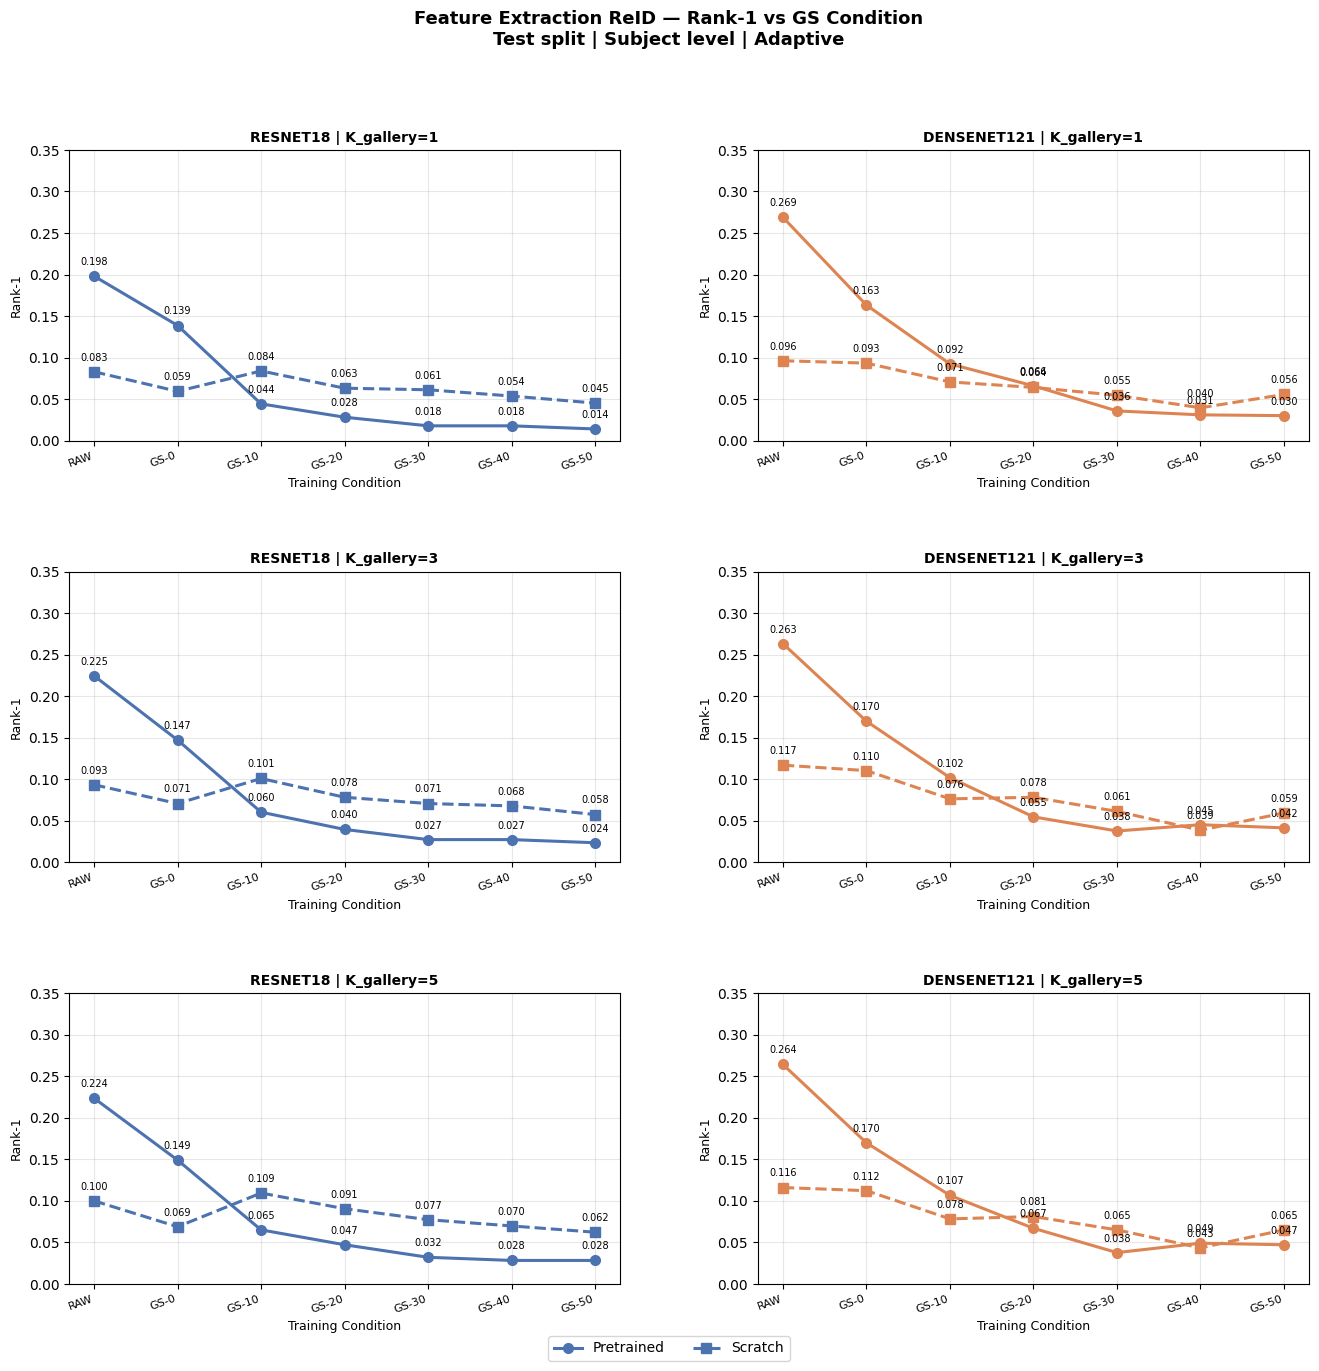

Saved → fig1_rank1_all_k.png


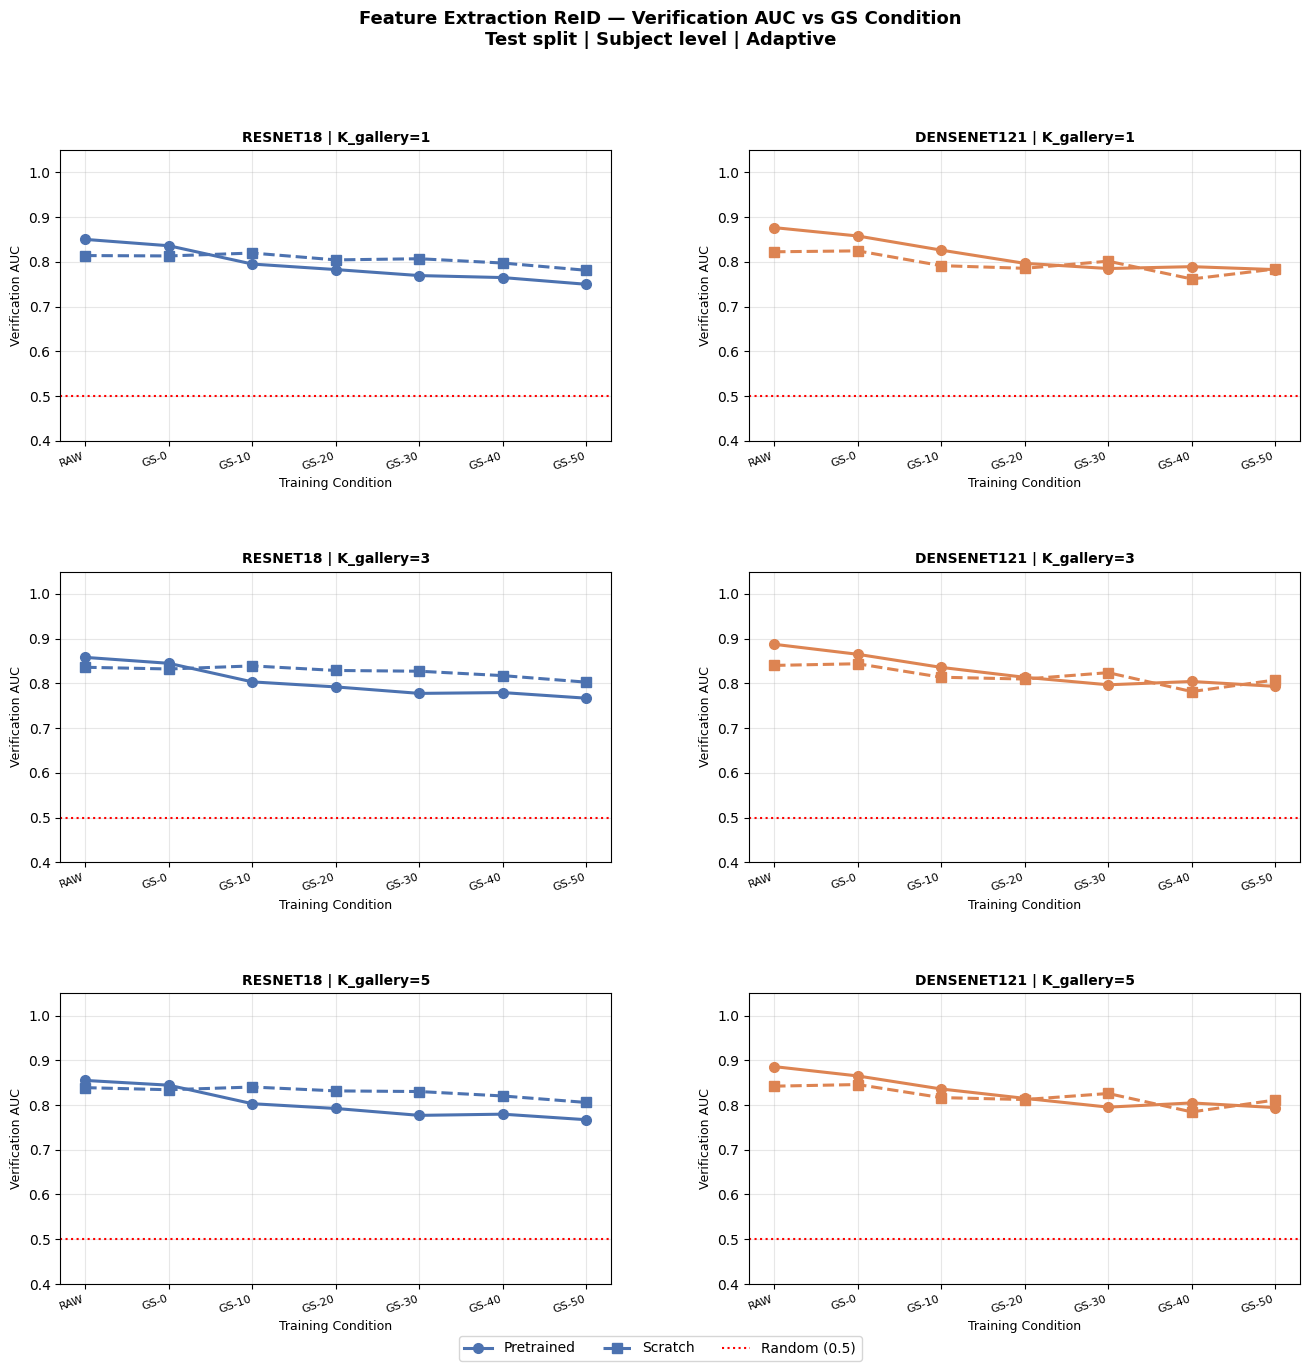

Saved → fig2_auc_all_k.png


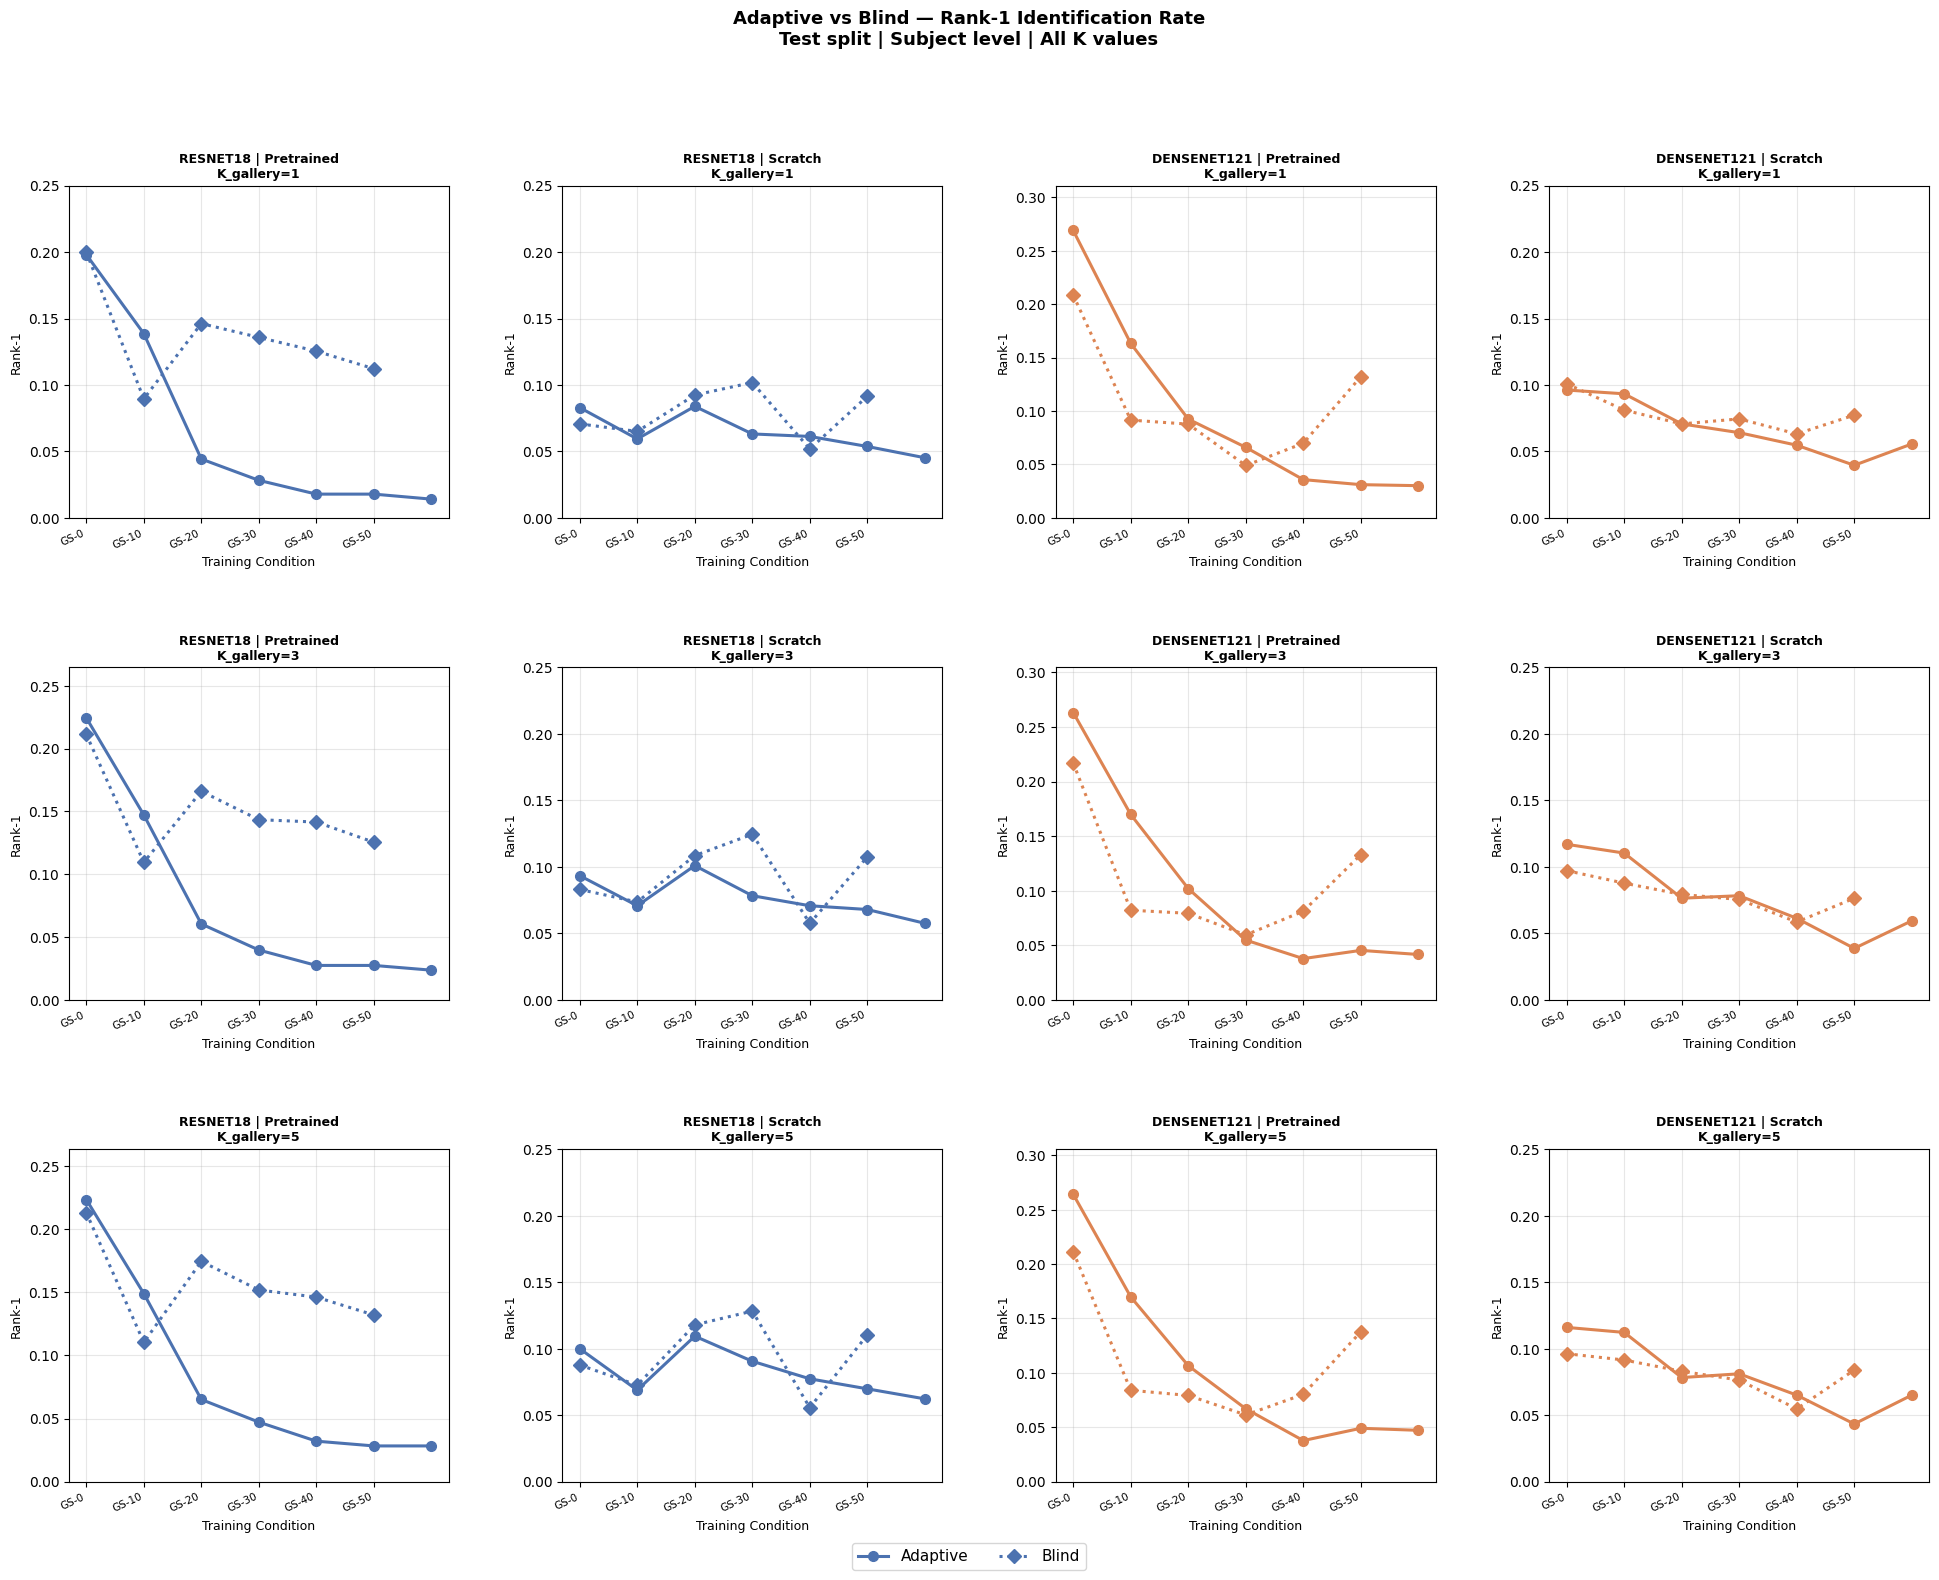

Saved → fig3_adaptive_vs_blind_all_k.png


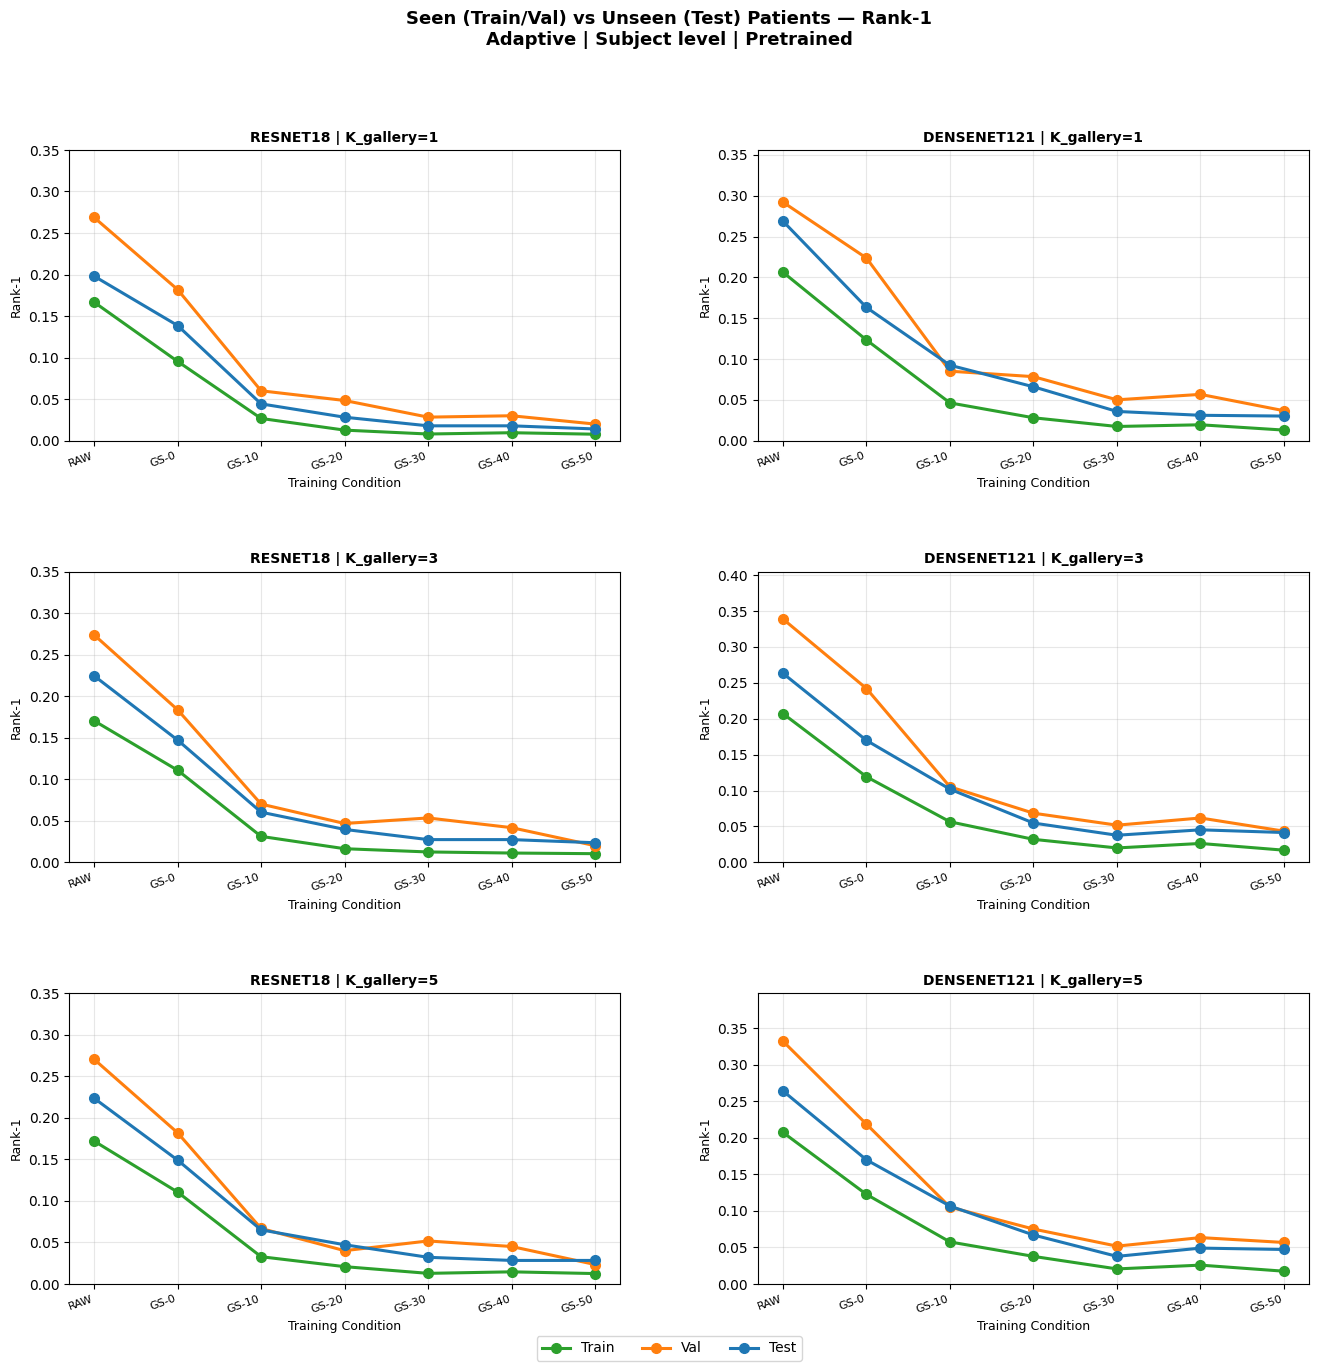

Saved → fig4_seen_vs_unseen_all_k.png

=== ALL FIGURES SAVED TO results/nih_cxr/reid_feature_ext/figures ===
  .ipynb_checkpoints
  fig1_rank1_all_k.png
  fig2_auc_all_k.png
  fig3_adaptive_vs_blind_all_k.png
  fig4_seen_vs_unseen_all_k.png


In [7]:
# =============================================================================
# VISUALISATION — All K values, fixed layout
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import re
from pathlib import Path

RESULTS_DIR = Path('./results/nih_cxr/reid_feature_ext')
FIG_DIR     = RESULTS_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(RESULTS_DIR / 'NIH_CXR_ReID_FeatureExt.csv')

# ── Condition parsing ─────────────────────────────────────────────────────────
def parse_condition(cond: str):
    c = str(cond).strip().lower()
    if c == 'raw':
        return ('RAW', -1)
    m = re.match(r'gs(\d+)$', c)
    if m:
        k = int(m.group(1))
        return (f'GS-{k}', k)
    raise ValueError(f"Unknown condition: {cond}")

for col in ['cond_label', 'cond_sort']:
    if col in df.columns:
        df = df.drop(columns=[col])

df['cond_label'] = df['train_condition'].apply(lambda x: parse_condition(x)[0])
df['cond_sort']  = df['train_condition'].apply(lambda x: parse_condition(x)[1])
df = df.sort_values('cond_sort')

ARCH_COLORS = {'resnet18': '#4C72B0', 'densenet121': '#DD8452'}
INIT_LINES  = {'pretrained': ('-',  'o'), 'scratch': ('--', 's')}
K_GALLERY   = [1, 3, 5]
ARCHITECTURES = ['resnet18', 'densenet121']
INITS         = ['pretrained', 'scratch']


def get_xy(sub_df, metric='rank1'):
    sub_df = sub_df.sort_values('cond_sort')
    return sub_df['cond_label'].tolist(), \
           pd.to_numeric(sub_df[metric], errors='coerce').tolist()


# =============================================================================
# FIGURE 1 — Rank-1 vs GS | All K | Test | Subject | Adaptive
# Rows: K=1, K=3, K=5  |  Cols: ResNet18, DenseNet121
# =============================================================================
fig, axes = plt.subplots(
    3, 2, figsize=(16, 14),
    gridspec_kw={'hspace': 0.45, 'wspace': 0.25}
)
fig.suptitle(
    'Feature Extraction ReID — Rank-1 vs GS Condition\n'
    'Test split | Subject level | Adaptive',
    fontsize=13, fontweight='bold', y=0.98
)

handle_store = None
label_store  = None

for row_idx, kg in enumerate(K_GALLERY):
    for col_idx, arch in enumerate(ARCHITECTURES):
        ax = axes[row_idx][col_idx]

        for init in INITS:
            sub = df[
                (df['eval_split']    == 'test') &
                (df['level']         == 'subject_level') &
                (df['k_gallery']     == kg) &
                (df['k_probe']       == 1) &
                (df['attacker_type'] == 'adaptive') &
                (df['arch']          == arch) &
                (df['init']          == init)
            ]
            if sub.empty:
                continue
            labels, ys = get_xy(sub, 'rank1')
            xs = list(range(len(labels)))
            ls, mk = INIT_LINES[init]
            line, = ax.plot(
                xs, ys,
                linestyle=ls, marker=mk,
                color=ARCH_COLORS[arch],
                linewidth=2.2, markersize=7,
                label=init.capitalize()
            )
            for x, y in zip(xs, ys):
                ax.annotate(
                    f'{y:.3f}', (x, y),
                    textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=7
                )

        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, fontsize=8, rotation=20, ha='right')
        ax.set_ylim(0, max(0.35, ax.get_ylim()[1] + 0.05))
        ax.set_ylabel('Rank-1', fontsize=9)
        ax.set_xlabel('Training Condition', fontsize=9)
        ax.set_title(
            f'{arch.upper()} | K_gallery={kg}',
            fontsize=10, fontweight='bold'
        )
        ax.grid(alpha=0.3)

        if handle_store is None:
            handle_store, label_store = ax.get_legend_handles_labels()

# Single shared legend at bottom
fig.legend(
    handle_store, label_store,
    loc='lower center', ncol=len(label_store),
    fontsize=10, frameon=True,
    bbox_to_anchor=(0.5, 0.01)
)
plt.subplots_adjust(bottom=0.07)
plt.savefig(FIG_DIR / 'fig1_rank1_all_k.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → fig1_rank1_all_k.png")


# =============================================================================
# FIGURE 2 — Verification AUC | All K | Test | Subject | Adaptive
# Rows: K=1, K=3, K=5  |  Cols: ResNet18, DenseNet121
# =============================================================================
fig, axes = plt.subplots(
    3, 2, figsize=(16, 14),
    gridspec_kw={'hspace': 0.45, 'wspace': 0.25}
)
fig.suptitle(
    'Feature Extraction ReID — Verification AUC vs GS Condition\n'
    'Test split | Subject level | Adaptive',
    fontsize=13, fontweight='bold', y=0.98
)

handle_store = None

for row_idx, kg in enumerate(K_GALLERY):
    for col_idx, arch in enumerate(ARCHITECTURES):
        ax = axes[row_idx][col_idx]

        for init in INITS:
            sub = df[
                (df['eval_split']    == 'test') &
                (df['level']         == 'subject_level') &
                (df['k_gallery']     == kg) &
                (df['k_probe']       == 1) &
                (df['attacker_type'] == 'adaptive') &
                (df['arch']          == arch) &
                (df['init']          == init)
            ]
            if sub.empty:
                continue
            labels, ys = get_xy(sub, 'auc')
            xs = list(range(len(labels)))
            ls, mk = INIT_LINES[init]
            ax.plot(
                xs, ys,
                linestyle=ls, marker=mk,
                color=ARCH_COLORS[arch],
                linewidth=2.2, markersize=7,
                label=init.capitalize()
            )

        ax.axhline(0.5, color='red', linestyle=':', linewidth=1.5,
                   label='Random (0.5)')
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, fontsize=8, rotation=20, ha='right')
        ax.set_ylim(0.4, 1.05)
        ax.set_ylabel('Verification AUC', fontsize=9)
        ax.set_xlabel('Training Condition', fontsize=9)
        ax.set_title(
            f'{arch.upper()} | K_gallery={kg}',
            fontsize=10, fontweight='bold'
        )
        ax.grid(alpha=0.3)

        if handle_store is None:
            handle_store, label_store = ax.get_legend_handles_labels()

fig.legend(
    handle_store, label_store,
    loc='lower center', ncol=len(label_store),
    fontsize=10, frameon=True,
    bbox_to_anchor=(0.5, 0.01)
)
plt.subplots_adjust(bottom=0.07)
plt.savefig(FIG_DIR / 'fig2_auc_all_k.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → fig2_auc_all_k.png")


# =============================================================================
# FIGURE 3 — Adaptive vs Blind | All K | Test | Subject
# Rows: K=1, K=3, K=5  |  Cols: ResNet18 Pretrained, ResNet18 Scratch,
#                               DenseNet121 Pretrained, DenseNet121 Scratch
# =============================================================================

fig, axes = plt.subplots(
    3, 4, figsize=(24, 16),
    gridspec_kw={'hspace': 0.45, 'wspace': 0.3}
)
fig.suptitle(
    'Adaptive vs Blind — Rank-1 Identification Rate\n'
    'Test split | Subject level | All K values',
    fontsize=13, fontweight='bold', y=0.99
)

ATCK_STYLE  = {'adaptive': '-',  'blind': ':'}
ATCK_MARKER = {'adaptive': 'o',  'blind': 'D'}
handle_store = None
label_store  = None

for row_idx, kg in enumerate(K_GALLERY):
    col_idx_global = 0
    for arch in ARCHITECTURES:
        for init in INITS:
            ax = axes[row_idx][col_idx_global]

            for attacker in ['adaptive', 'blind']:
                sub = df[
                    (df['eval_split']    == 'test') &
                    (df['level']         == 'subject_level') &
                    (df['k_gallery']     == kg) &
                    (df['k_probe']       == 1) &
                    (df['attacker_type'] == attacker) &
                    (df['arch']          == arch) &
                    (df['init']          == init)
                ]
                if sub.empty:
                    col_idx_global += 1
                    continue
                labels, ys = get_xy(sub, 'rank1')
                xs = list(range(len(labels)))
                ax.plot(
                    xs, ys,
                    linestyle  = ATCK_STYLE[attacker],
                    marker     = ATCK_MARKER[attacker],
                    color      = ARCH_COLORS[arch],
                    linewidth  = 2.2,
                    markersize = 7,
                    label      = attacker.capitalize()
                )

            ax.set_xticks(range(len(labels)))
            ax.set_xticklabels(
                labels, fontsize=7.5, rotation=25, ha='right'
            )
            ymax = max(0.25, ax.get_ylim()[1] + 0.03)
            ax.set_ylim(0, ymax)
            ax.set_ylabel('Rank-1', fontsize=9)
            ax.set_xlabel('Training Condition', fontsize=9)
            ax.set_title(
                f'{arch.upper()} | {init.capitalize()}\n'
                f'K_gallery={kg}',
                fontsize=9, fontweight='bold'
            )
            ax.grid(alpha=0.3)

            if handle_store is None:
                handle_store, label_store = \
                    ax.get_legend_handles_labels()

            col_idx_global += 1

# Single shared legend at bottom
fig.legend(
    handle_store, label_store,
    loc          = 'lower center',
    ncol         = len(label_store),
    fontsize     = 11,
    frameon      = True,
    bbox_to_anchor = (0.5, 0.01)
)
plt.subplots_adjust(bottom=0.07)
plt.savefig(
    FIG_DIR / 'fig3_adaptive_vs_blind_all_k.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Saved → fig3_adaptive_vs_blind_all_k.png")


# =============================================================================
# FIGURE 4 — Seen vs Unseen | All K | Subject | Adaptive | Pretrained
# Rows: K=1, K=3, K=5  |  Cols: ResNet18, DenseNet121
# =============================================================================
SPLIT_COLORS = {'train': '#2ca02c', 'val': '#ff7f0e', 'test': '#1f77b4'}

fig, axes = plt.subplots(
    3, 2, figsize=(16, 14),
    gridspec_kw={'hspace': 0.45, 'wspace': 0.25}
)
fig.suptitle(
    'Seen (Train/Val) vs Unseen (Test) Patients — Rank-1\n'
    'Adaptive | Subject level | Pretrained',
    fontsize=13, fontweight='bold', y=0.98
)

handle_store = None

for row_idx, kg in enumerate(K_GALLERY):
    for col_idx, arch in enumerate(ARCHITECTURES):
        ax = axes[row_idx][col_idx]

        for split in ['train', 'val', 'test']:
            sub = df[
                (df['eval_split']    == split) &
                (df['level']         == 'subject_level') &
                (df['k_gallery']     == kg) &
                (df['k_probe']       == 1) &
                (df['attacker_type'] == 'adaptive') &
                (df['arch']          == arch) &
                (df['init']          == 'pretrained')
            ]
            if sub.empty:
                continue
            labels, ys = get_xy(sub, 'rank1')
            xs = list(range(len(labels)))
            ax.plot(
                xs, ys,
                marker='o', linewidth=2.2, markersize=7,
                color=SPLIT_COLORS[split],
                label=split.capitalize()
            )

        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, fontsize=8, rotation=20, ha='right')
        ax.set_ylim(0, max(0.35, ax.get_ylim()[1] + 0.05))
        ax.set_ylabel('Rank-1', fontsize=9)
        ax.set_xlabel('Training Condition', fontsize=9)
        ax.set_title(
            f'{arch.upper()} | K_gallery={kg}',
            fontsize=10, fontweight='bold'
        )
        ax.grid(alpha=0.3)

        if handle_store is None:
            handle_store, label_store = ax.get_legend_handles_labels()

fig.legend(
    handle_store, label_store,
    loc='lower center', ncol=len(label_store),
    fontsize=10, frameon=True,
    bbox_to_anchor=(0.5, 0.01)
)
plt.subplots_adjust(bottom=0.07)
plt.savefig(FIG_DIR / 'fig4_seen_vs_unseen_all_k.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → fig4_seen_vs_unseen_all_k.png")


print(f"\n=== ALL FIGURES SAVED TO {FIG_DIR} ===")
for f in sorted(FIG_DIR.iterdir()):
    print(f"  {f.name}")

In [8]:
# Quick audit of blind results
blind_df = df[df['attacker_type'] == 'blind'].copy()

print(f"Total blind rows: {len(blind_df)}")
print(f"\nTrain conditions (blind): {sorted(blind_df['train_condition'].unique())}")
print(f"Note: raw is excluded from blind (no blind eval for raw condition)")
print(f"\nBlind row counts by metric availability:")
print(blind_df.groupby(['k_gallery', 'level', 'eval_split']).size().to_string())
print(f"\nSample blind AUC values (test, subject, k=1):")
check = blind_df[
    (blind_df['eval_split'] == 'test') &
    (blind_df['level']      == 'subject_level') &
    (blind_df['k_gallery']  == 1)
][['arch','init','train_condition','rank1','auc']].sort_values(
    ['arch','init','train_condition']
)
print(check.to_string(index=False))

Total blind rows: 432

Train conditions (blind): ['gs0', 'gs10', 'gs20', 'gs30', 'gs40', 'gs50']
Note: raw is excluded from blind (no blind eval for raw condition)

Blind row counts by metric availability:
k_gallery  level          eval_split
1          slice_level    test          24
                          train         24
                          val           24
           subject_level  test          24
                          train         24
                          val           24
3          slice_level    test          24
                          train         24
                          val           24
           subject_level  test          24
                          train         24
                          val           24
5          slice_level    test          24
                          train         24
                          val           24
           subject_level  test          24
                          train         24
                          

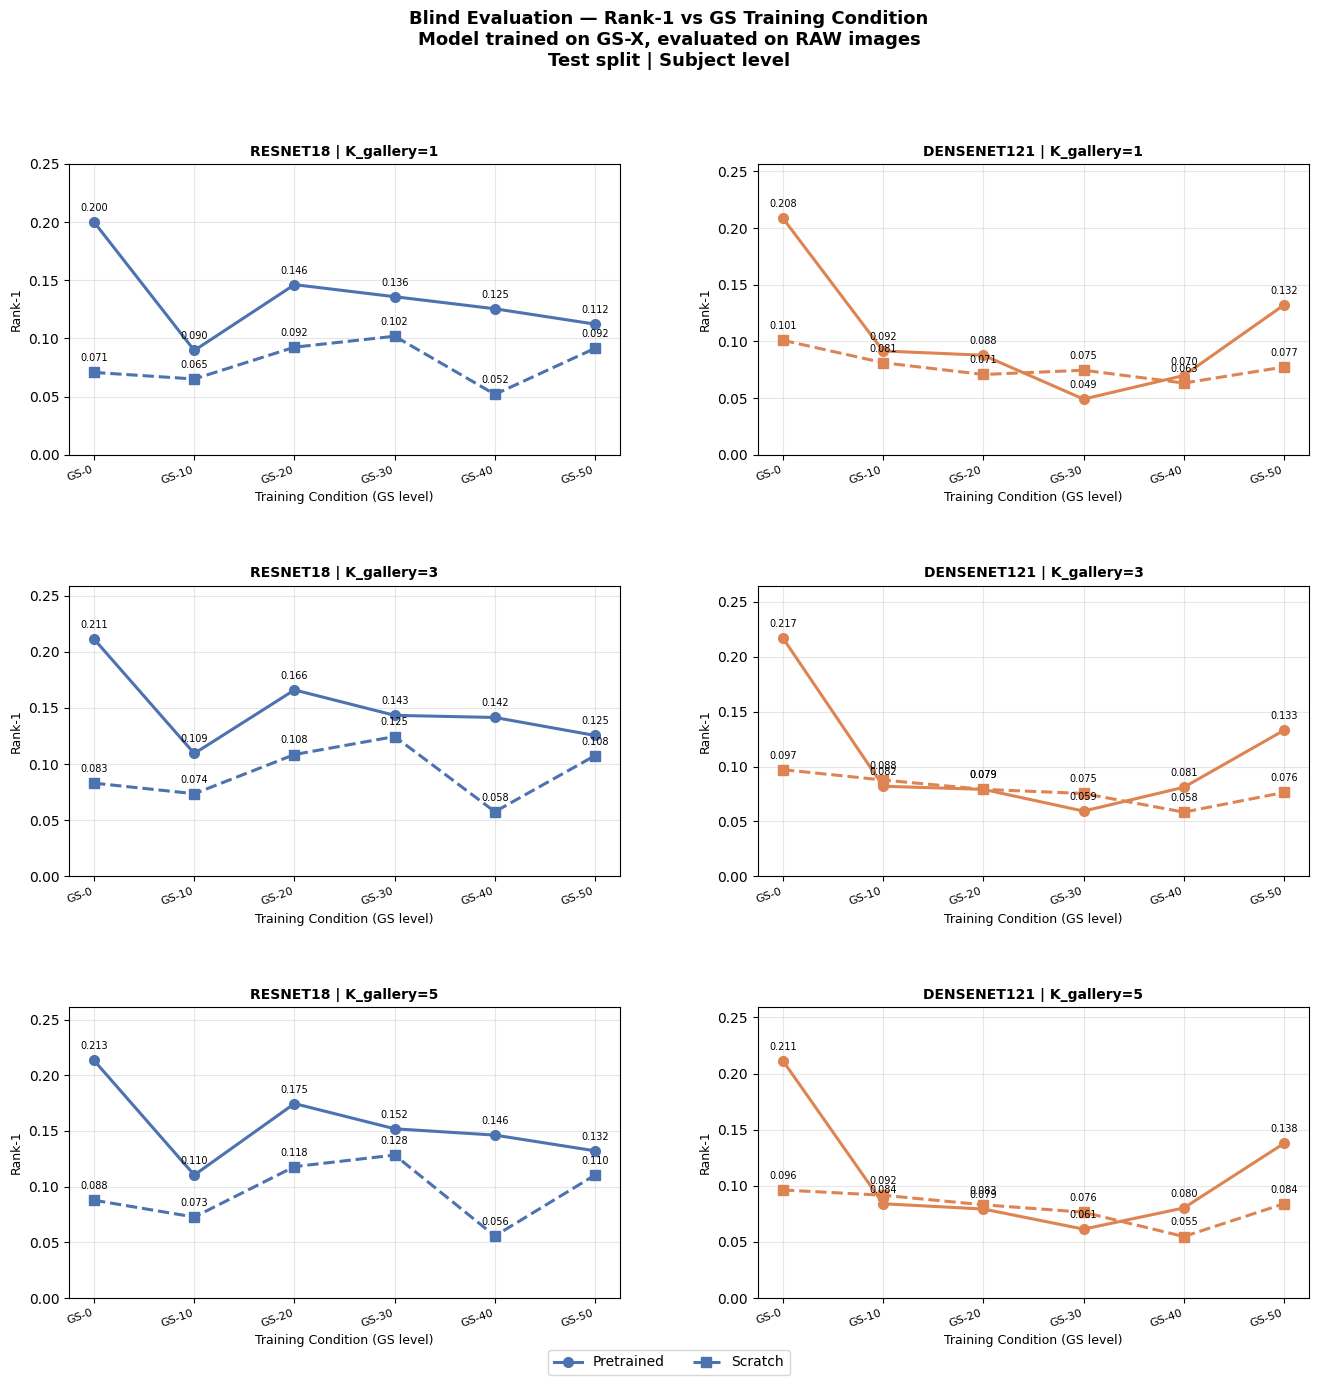

Saved → figB1_blind_rank1_all_k.png


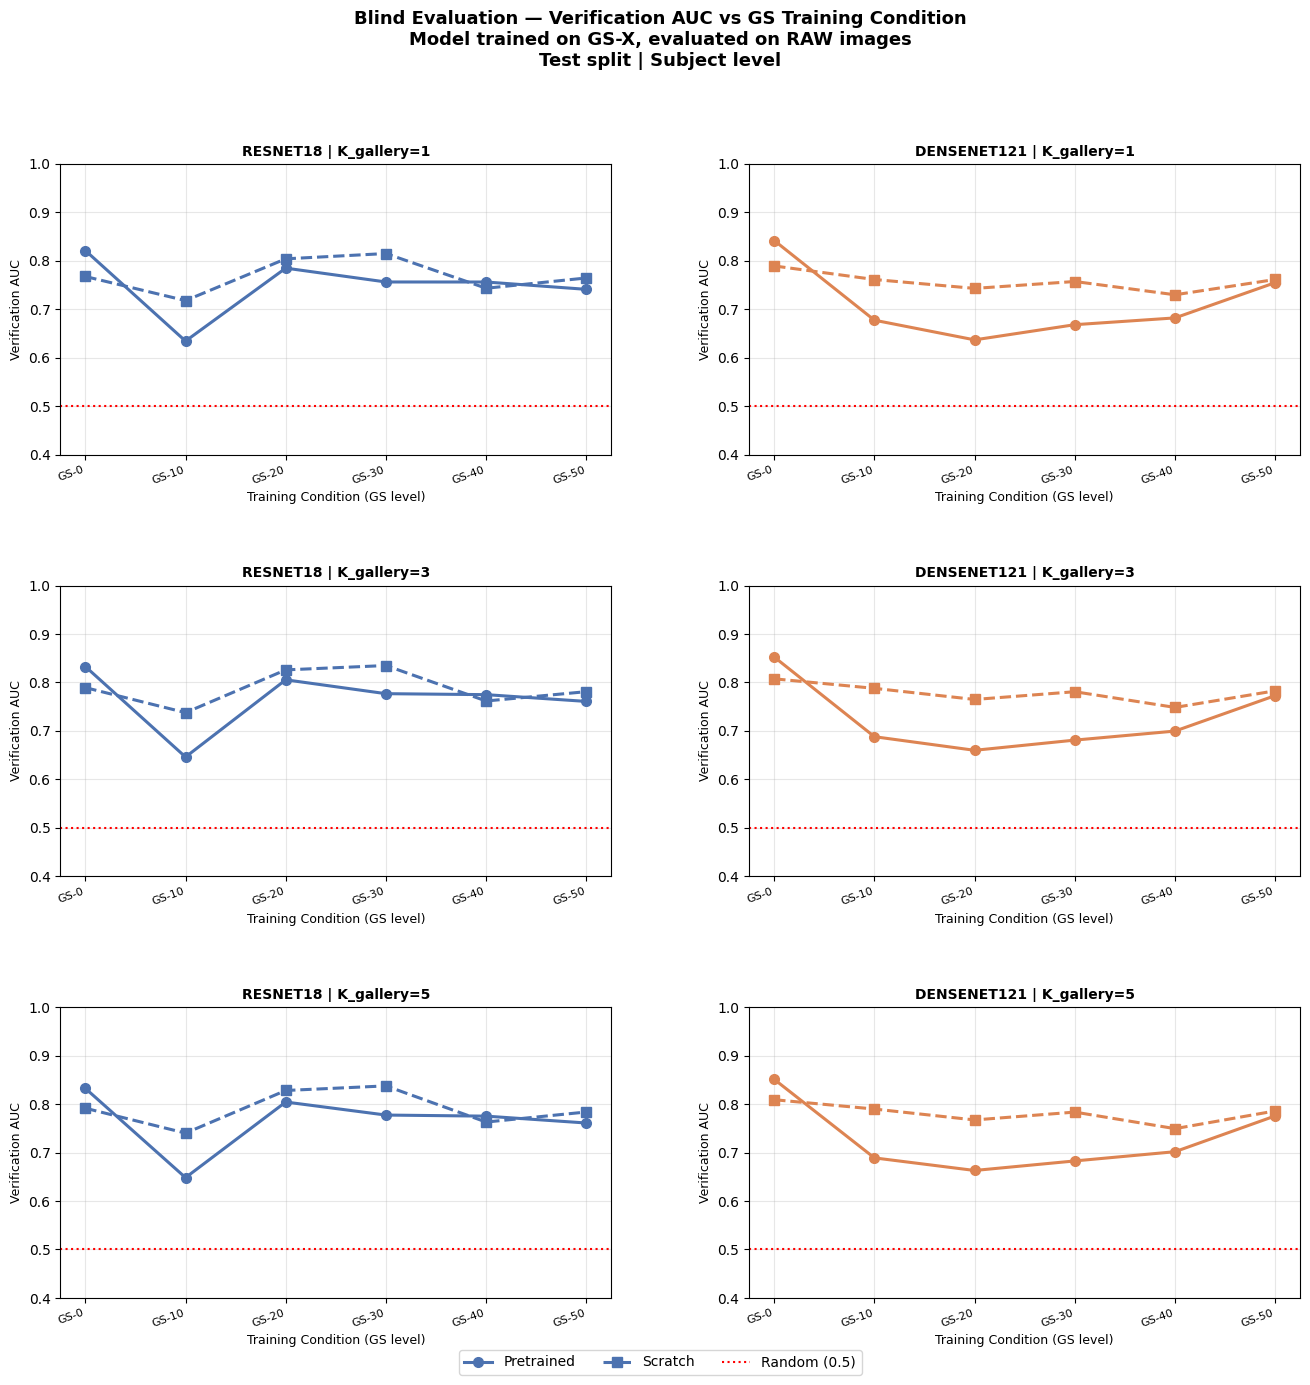

Saved → figB2_blind_auc_all_k.png


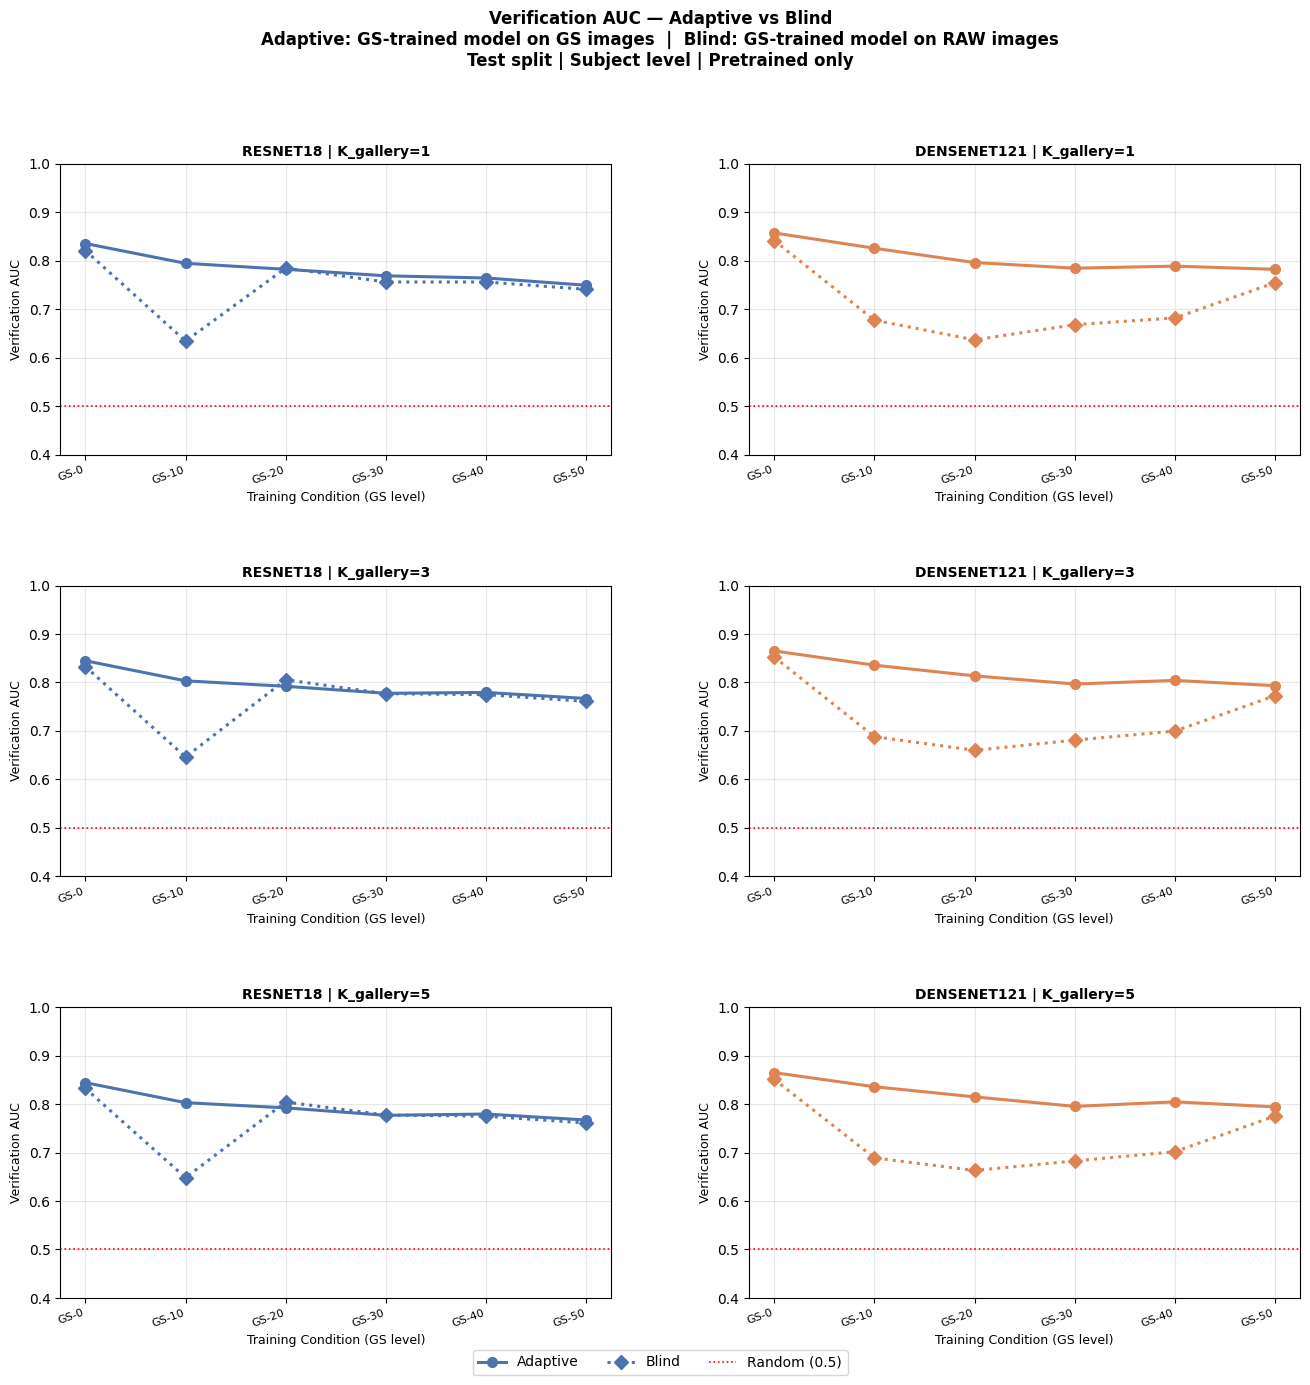

Saved → figB3_auc_adaptive_vs_blind_all_k.png


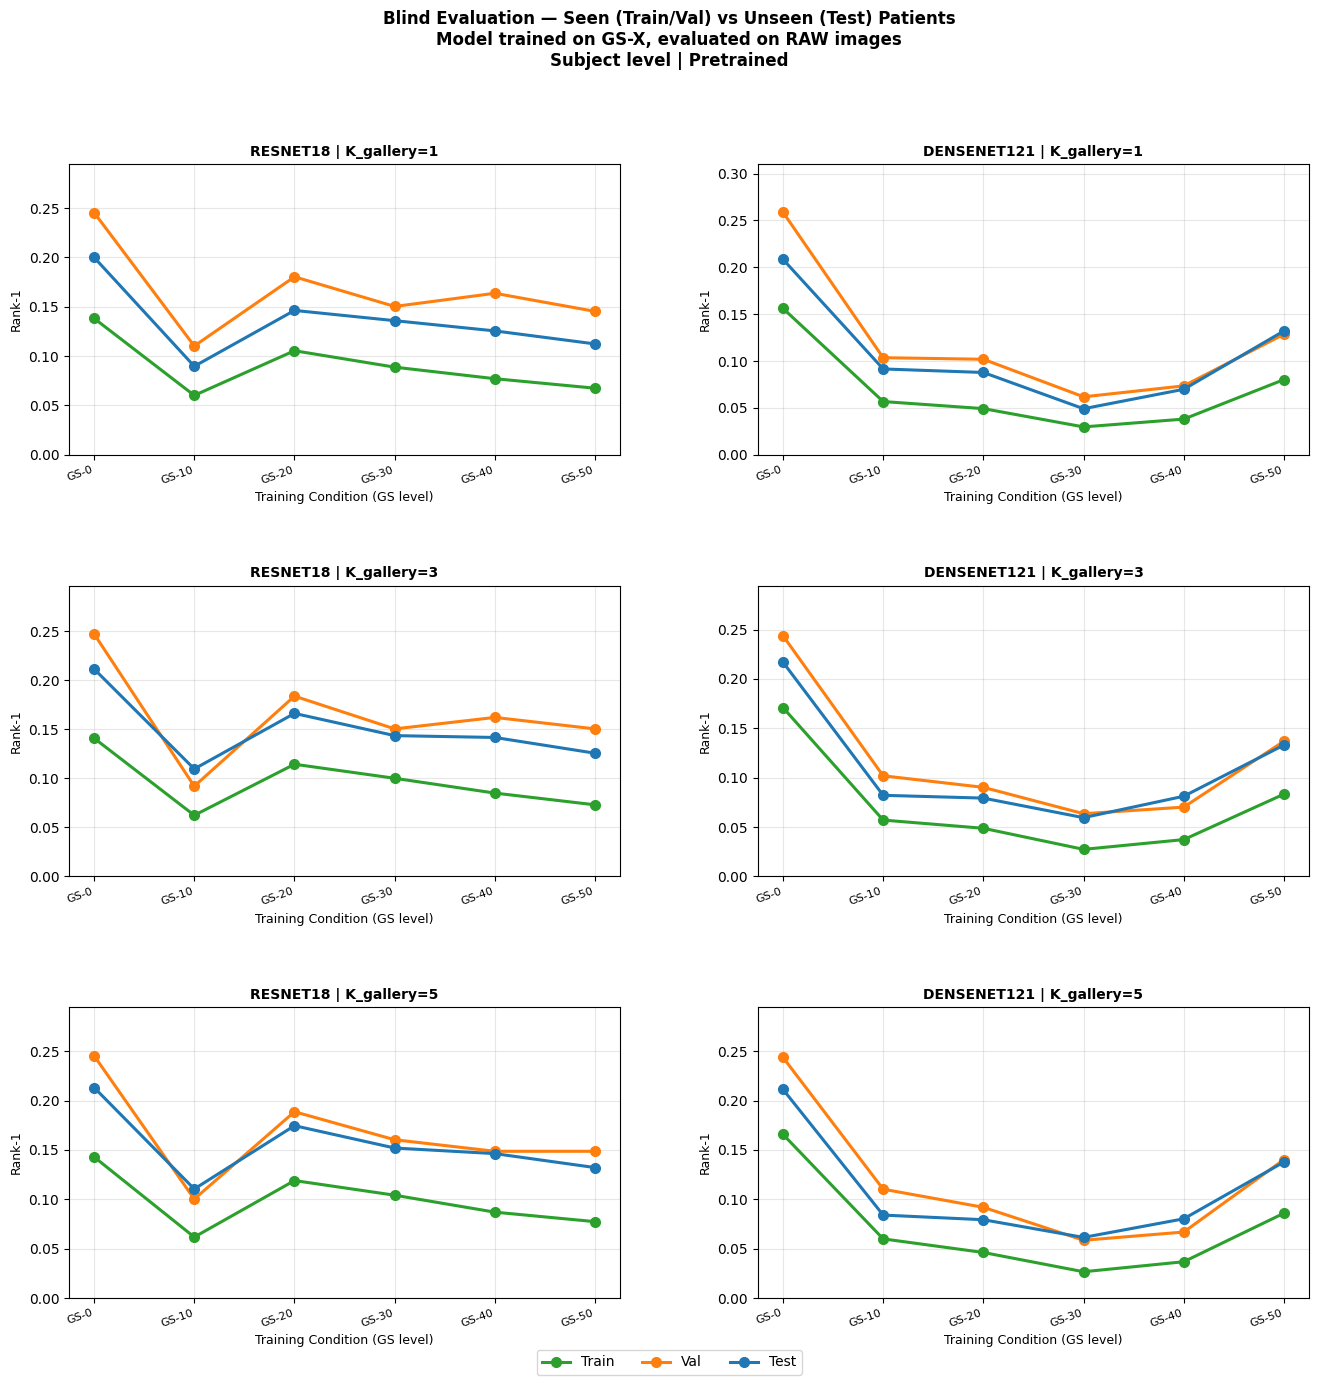

Saved → figB4_blind_seen_vs_unseen_all_k.png

=== BLIND FIGURES SAVED ===
  figB1_blind_rank1_all_k.png
  figB2_blind_auc_all_k.png
  figB3_auc_adaptive_vs_blind_all_k.png
  figB4_blind_seen_vs_unseen_all_k.png


In [9]:
# =============================================================================
# BLIND-ONLY PLOTS
# Plots missing from existing figures:
#   Fig B1 — Blind Rank-1 vs GS | All K | Test | Subject
#   Fig B2 — Blind Verification AUC vs GS | All K | Test | Subject
#   Fig B3 — Adaptive vs Blind AUC side-by-side | K=1 | Test | Subject
#   Fig B4 — Blind Seen vs Unseen | All K | Subject | Pretrained
# =============================================================================

blind_df = df[df['attacker_type'] == 'blind'].copy()
adap_df  = df[df['attacker_type'] == 'adaptive'].copy()

# Conditions for blind (no raw)
BLIND_CONDITIONS = ['gs0','gs10','gs20','gs30','gs40','gs50']
BLIND_LABELS     = ['GS-0','GS-10','GS-20','GS-30','GS-40','GS-50']


# =============================================================================
# Fig B1 — Blind Rank-1 | All K | Test | Subject
# Rows: K=1,3,5  |  Cols: ResNet18, DenseNet121
# =============================================================================
fig, axes = plt.subplots(
    3, 2, figsize=(16, 14),
    gridspec_kw={'hspace': 0.45, 'wspace': 0.25}
)
fig.suptitle(
    'Blind Evaluation — Rank-1 vs GS Training Condition\n'
    'Model trained on GS-X, evaluated on RAW images\n'
    'Test split | Subject level',
    fontsize=13, fontweight='bold', y=0.99
)

handle_store = label_store = None

for row_idx, kg in enumerate(K_GALLERY):
    for col_idx, arch in enumerate(ARCHITECTURES):
        ax = axes[row_idx][col_idx]

        for init in INITS:
            sub = blind_df[
                (blind_df['eval_split'] == 'test') &
                (blind_df['level']      == 'subject_level') &
                (blind_df['k_gallery']  == kg) &
                (blind_df['k_probe']    == 1) &
                (blind_df['arch']       == arch) &
                (blind_df['init']       == init)
            ].sort_values('cond_sort')
            if sub.empty:
                continue
            labels = sub['cond_label'].tolist()
            ys     = pd.to_numeric(sub['rank1'], errors='coerce').tolist()
            xs     = list(range(len(labels)))
            ls, mk = INIT_LINES[init]
            ax.plot(
                xs, ys,
                linestyle=ls, marker=mk,
                color=ARCH_COLORS[arch],
                linewidth=2.2, markersize=7,
                label=init.capitalize()
            )
            for x, y in zip(xs, ys):
                ax.annotate(
                    f'{y:.3f}', (x, y),
                    textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=7
                )

        ax.set_xticks(range(len(BLIND_LABELS)))
        ax.set_xticklabels(BLIND_LABELS, fontsize=8, rotation=20, ha='right')
        ax.set_ylim(0, max(0.25, ax.get_ylim()[1] + 0.04))
        ax.set_ylabel('Rank-1', fontsize=9)
        ax.set_xlabel('Training Condition (GS level)', fontsize=9)
        ax.set_title(
            f'{arch.upper()} | K_gallery={kg}',
            fontsize=10, fontweight='bold'
        )
        ax.grid(alpha=0.3)

        if handle_store is None:
            handle_store, label_store = ax.get_legend_handles_labels()

fig.legend(
    handle_store, label_store,
    loc='lower center', ncol=len(label_store),
    fontsize=10, frameon=True,
    bbox_to_anchor=(0.5, 0.01)
)
plt.subplots_adjust(bottom=0.07)
plt.savefig(FIG_DIR / 'figB1_blind_rank1_all_k.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figB1_blind_rank1_all_k.png")


# =============================================================================
# Fig B2 — Blind Verification AUC | All K | Test | Subject
# Rows: K=1,3,5  |  Cols: ResNet18, DenseNet121
# =============================================================================
fig, axes = plt.subplots(
    3, 2, figsize=(16, 14),
    gridspec_kw={'hspace': 0.45, 'wspace': 0.25}
)
fig.suptitle(
    'Blind Evaluation — Verification AUC vs GS Training Condition\n'
    'Model trained on GS-X, evaluated on RAW images\n'
    'Test split | Subject level',
    fontsize=13, fontweight='bold', y=0.99
)

handle_store = label_store = None

for row_idx, kg in enumerate(K_GALLERY):
    for col_idx, arch in enumerate(ARCHITECTURES):
        ax = axes[row_idx][col_idx]

        for init in INITS:
            sub = blind_df[
                (blind_df['eval_split'] == 'test') &
                (blind_df['level']      == 'subject_level') &
                (blind_df['k_gallery']  == kg) &
                (blind_df['k_probe']    == 1) &
                (blind_df['arch']       == arch) &
                (blind_df['init']       == init)
            ].sort_values('cond_sort')
            if sub.empty:
                continue
            labels = sub['cond_label'].tolist()
            ys     = pd.to_numeric(sub['auc'], errors='coerce').tolist()
            xs     = list(range(len(labels)))
            ls, mk = INIT_LINES[init]
            ax.plot(
                xs, ys,
                linestyle=ls, marker=mk,
                color=ARCH_COLORS[arch],
                linewidth=2.2, markersize=7,
                label=init.capitalize()
            )

        ax.axhline(0.5, color='red', linestyle=':', linewidth=1.5,
                   label='Random (0.5)')
        ax.set_xticks(range(len(BLIND_LABELS)))
        ax.set_xticklabels(BLIND_LABELS, fontsize=8, rotation=20, ha='right')
        ax.set_ylim(0.4, 1.0)
        ax.set_ylabel('Verification AUC', fontsize=9)
        ax.set_xlabel('Training Condition (GS level)', fontsize=9)
        ax.set_title(
            f'{arch.upper()} | K_gallery={kg}',
            fontsize=10, fontweight='bold'
        )
        ax.grid(alpha=0.3)

        if handle_store is None:
            handle_store, label_store = ax.get_legend_handles_labels()

fig.legend(
    handle_store, label_store,
    loc='lower center', ncol=len(label_store),
    fontsize=10, frameon=True,
    bbox_to_anchor=(0.5, 0.01)
)
plt.subplots_adjust(bottom=0.07)
plt.savefig(FIG_DIR / 'figB2_blind_auc_all_k.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figB2_blind_auc_all_k.png")


# =============================================================================
# Fig B3 — Adaptive vs Blind AUC side-by-side | All K | Test | Subject
# Rows: K=1,3,5  |  Cols: ResNet18, DenseNet121
# Shows AUC gap between adaptive (GS test) and blind (raw test)
# =============================================================================
fig, axes = plt.subplots(
    3, 2, figsize=(16, 14),
    gridspec_kw={'hspace': 0.45, 'wspace': 0.25}
)
fig.suptitle(
    'Verification AUC — Adaptive vs Blind\n'
    'Adaptive: GS-trained model on GS images  |  '
    'Blind: GS-trained model on RAW images\n'
    'Test split | Subject level | Pretrained only',
    fontsize=12, fontweight='bold', y=0.99
)

ATCK_STYLE_AUC  = {'adaptive': '-',  'blind': ':'}
ATCK_MARKER_AUC = {'adaptive': 'o',  'blind': 'D'}
ATCK_LABEL      = {'adaptive': 'Adaptive', 'blind': 'Blind'}

handle_store = label_store = None

for row_idx, kg in enumerate(K_GALLERY):
    for col_idx, arch in enumerate(ARCHITECTURES):
        ax = axes[row_idx][col_idx]

        for attacker, src_df in [('adaptive', adap_df),
                                  ('blind',    blind_df)]:
            sub = src_df[
                (src_df['eval_split'] == 'test') &
                (src_df['level']      == 'subject_level') &
                (src_df['k_gallery']  == kg) &
                (src_df['k_probe']    == 1) &
                (src_df['arch']       == arch) &
                (src_df['init']       == 'pretrained')
            ].sort_values('cond_sort')

            # Adaptive includes raw condition; blind does not
            # For fair comparison show only GS conditions on x-axis
            sub = sub[sub['train_condition'] != 'raw']
            if sub.empty:
                continue

            labels = sub['cond_label'].tolist()
            ys     = pd.to_numeric(sub['auc'], errors='coerce').tolist()
            xs     = list(range(len(labels)))

            ax.plot(
                xs, ys,
                linestyle  = ATCK_STYLE_AUC[attacker],
                marker     = ATCK_MARKER_AUC[attacker],
                color      = ARCH_COLORS[arch],
                linewidth  = 2.2, markersize=7,
                label      = ATCK_LABEL[attacker]
            )

        ax.axhline(0.5, color='red', linestyle=':', linewidth=1.2,
                   label='Random (0.5)')
        ax.set_xticks(range(len(BLIND_LABELS)))
        ax.set_xticklabels(BLIND_LABELS, fontsize=8, rotation=20, ha='right')
        ax.set_ylim(0.4, 1.0)
        ax.set_ylabel('Verification AUC', fontsize=9)
        ax.set_xlabel('Training Condition (GS level)', fontsize=9)
        ax.set_title(
            f'{arch.upper()} | K_gallery={kg}',
            fontsize=10, fontweight='bold'
        )
        ax.grid(alpha=0.3)

        if handle_store is None:
            handle_store, label_store = ax.get_legend_handles_labels()

fig.legend(
    handle_store, label_store,
    loc='lower center', ncol=len(label_store),
    fontsize=10, frameon=True,
    bbox_to_anchor=(0.5, 0.01)
)
plt.subplots_adjust(bottom=0.07)
plt.savefig(FIG_DIR / 'figB3_auc_adaptive_vs_blind_all_k.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figB3_auc_adaptive_vs_blind_all_k.png")


# =============================================================================
# Fig B4 — Blind Seen vs Unseen | All K | Subject | Pretrained
# Rows: K=1,3,5  |  Cols: ResNet18, DenseNet121
# =============================================================================
SPLIT_COLORS = {'train': '#2ca02c', 'val': '#ff7f0e', 'test': '#1f77b4'}

fig, axes = plt.subplots(
    3, 2, figsize=(16, 14),
    gridspec_kw={'hspace': 0.45, 'wspace': 0.25}
)
fig.suptitle(
    'Blind Evaluation — Seen (Train/Val) vs Unseen (Test) Patients\n'
    'Model trained on GS-X, evaluated on RAW images\n'
    'Subject level | Pretrained',
    fontsize=12, fontweight='bold', y=0.99
)

handle_store = label_store = None

for row_idx, kg in enumerate(K_GALLERY):
    for col_idx, arch in enumerate(ARCHITECTURES):
        ax = axes[row_idx][col_idx]

        for split in ['train', 'val', 'test']:
            sub = blind_df[
                (blind_df['eval_split'] == split) &
                (blind_df['level']      == 'subject_level') &
                (blind_df['k_gallery']  == kg) &
                (blind_df['k_probe']    == 1) &
                (blind_df['arch']       == arch) &
                (blind_df['init']       == 'pretrained')
            ].sort_values('cond_sort')
            if sub.empty:
                continue
            labels = sub['cond_label'].tolist()
            ys     = pd.to_numeric(sub['rank1'], errors='coerce').tolist()
            xs     = list(range(len(labels)))
            ax.plot(
                xs, ys,
                marker='o', linewidth=2.2, markersize=7,
                color=SPLIT_COLORS[split],
                label=split.capitalize()
            )

        ax.set_xticks(range(len(BLIND_LABELS)))
        ax.set_xticklabels(BLIND_LABELS, fontsize=8, rotation=20, ha='right')
        ax.set_ylim(0, max(0.25, ax.get_ylim()[1] + 0.04))
        ax.set_ylabel('Rank-1', fontsize=9)
        ax.set_xlabel('Training Condition (GS level)', fontsize=9)
        ax.set_title(
            f'{arch.upper()} | K_gallery={kg}',
            fontsize=10, fontweight='bold'
        )
        ax.grid(alpha=0.3)

        if handle_store is None:
            handle_store, label_store = ax.get_legend_handles_labels()

fig.legend(
    handle_store, label_store,
    loc='lower center', ncol=len(label_store),
    fontsize=10, frameon=True,
    bbox_to_anchor=(0.5, 0.01)
)
plt.subplots_adjust(bottom=0.07)
plt.savefig(FIG_DIR / 'figB4_blind_seen_vs_unseen_all_k.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figB4_blind_seen_vs_unseen_all_k.png")

print(f"\n=== BLIND FIGURES SAVED ===")
for f in sorted(FIG_DIR.iterdir()):
    if 'figB' in f.name:
        print(f"  {f.name}")